># <center><font color='red'>**Seasonal Agricultural Performance & Productivity Analysis**</font></center>
This project performs exploratory data analysis and visualization on agricultural data to identify seasonal patterns, productivity trends, profitability, resource efficiency, and disease/pest risk. The analysis examines factors such as environmental conditions, soil characteristics, farming inputs, irrigation methods, crop types, and market conditions that influence agricultural performance across seasons. The objective is to derive meaningful insights that support data-driven farming, resource allocation, crop planning, and agricultural decision-making.




>### **IMPORTING REQUIRED LIBRARIES & PACKAGES**

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

pd.options.display.float_format = '{:,.2f}'.format

>### **IMPORTING AND READING THE DATASET**

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/seasonal_agriculture_performance_dataset.csv')

>### **1.** **DATA EXPLORATION AND QUALITY ASSESSMENT**

In [3]:
# Dataset Dimensions before handling missing values

display(df.shape)
print("No.of Rows in the dataset:",df.shape[0])
print("No.of Columns in the dataset:",df.shape[1])

(4000, 28)

No.of Rows in the dataset: 4000
No.of Columns in the dataset: 28


In [4]:
# Column Overview

df.columns.to_list()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [5]:
# Initial Data Preview
# Exploring first 5 rows of the dataset

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [6]:
# Initial Data Preview
# Exploring last 5 rows of the dataset

df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [7]:
# Duplicate Record Detection

duplicate_rows = df[df.duplicated(keep=False)]

print(f"Total duplicate rows found: {len(duplicate_rows)}")
duplicate_rows

Total duplicate rows found: 0


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct


In [8]:
# Missing Value Detection

df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


>### **2.** **DATA CLEANING AND PREPROCESSING**


In [9]:
# Examine records with missing yield to understand their distribution

df[df['Yield_Tonnes_Ha'].isna()][
    ['State', 'District', 'Crop', 'Season', 'Yield_Tonnes_Ha']
]

,State,District,Crop,Season,Yield_Tonnes_Ha
55,Karnataka,Warangal,Groundnut,Rabi,NaN
163,Madhya Pradesh,Erode,Pulses,Zaid,NaN
555,Andhra Pradesh,Nashik,Chilli,Rabi,NaN
648,Andhra Pradesh,Krishna,Groundnut,Rabi,NaN
650,Gujarat,Raichur,Maize,Rabi,NaN
777,Gujarat,Ludhiana,Cotton,Rabi,NaN
874,Karnataka,Erode,Rice,Kharif,NaN
899,Tamil Nadu,Guntur,Pulses,Rabi,NaN
1133,Karnataka,Raichur,Cotton,Kharif,NaN
1251,Telangana,Warangal,Chilli,Zaid,NaN


In [10]:
# Create a temporary dataframe containing only records where yield is available

yield_df = df.dropna(subset=['Yield_Tonnes_Ha'])

In [11]:
# Number of rows and columns in yield_df after handling missing values

display(yield_df.shape)
print("No.of Rows in the dataset:",yield_df.shape[0])
print("No.of Columns in the dataset:",yield_df.shape[1])

(3968, 28)

No.of Rows in the dataset: 3968
No.of Columns in the dataset: 28


In [12]:
# First few records of yield_df after handling missing values

yield_df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [13]:
# Generate descriptive statistics for yield_df after handling missing values

yield_df['Yield_Tonnes_Ha'].describe()

,Yield_Tonnes_Ha
count,"3,968.00"
mean,5.27
std,13.36
min,0.30
25%,1.05
50%,1.74
75%,2.84
max,101.44


In [14]:
# Find the median rainfall for each State and Season
median_rainfall = df.groupby(['State', 'Season'])['Rainfall_mm'].transform('median')

# Fill missing rainfall values with the corresponding median
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(median_rainfall)

In [15]:
# Check if any null values remain

df['Rainfall_mm'].isnull().sum()

np.int64(0)

In [16]:
# Find the median soil moisture for each State and Season
median_soil_moisture = df.groupby(['State', 'Season'])['Soil_Moisture_pct'].transform('median')

# Fill missing soil moisture values with the corresponding median
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(median_soil_moisture)

In [17]:
# Check if any null values remain

df['Soil_Moisture_pct'].isnull().sum()

np.int64(0)

In [18]:
# Verify the dataset after handling missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    4000 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              4000 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [19]:
# Generate descriptive statistics after data cleaning

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",NaN,NaN,NaN,600.74,288.40,80.00,370.43,581.00,836.12,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


#### <font color='red'>**Key Findings from above Descriptive Statistics:**</font><br>
**1. Total Records:** The dataset contains 4,000 farm-level records across different states, districts, crops, and seasons.<br>
**2. Geographical Coverage:** The dataset includes 9 states and 10 districts, providing geographical variation in agricultural activities.<br>
**3. Crop Diversity:** The dataset contains 8 different crop types, allowing comparison of agricultural performance across crops.<br>
**4. Seasonal Coverage:** Agricultural activities are recorded across 3 different seasons, enabling seasonal performance analysis.<br>
**5. Farm Area:** Farm sizes range from 0.50 to 15 hectares, with an average farm area of approximately 7.89 hectares.<br>
**6. Rainfall:** Average rainfall is approximately 600.74 mm, with values ranging from 80 mm to 1,395.20 mm, indicating substantial variation in rainfall conditions.<br>
**7. Temperature:** The average temperature is approximately 26.82°C, ranging from 16.20°C to 39.70°C.<br>
**8. Humidity:** Average humidity is approximately 63.21%, with observations ranging from 25% to 95%.<br>
**9. Soil Moisture:** The average soil moisture level is approximately 26.50%, ranging from 8% to 47%.<br>
**10. Soil pH:** The average soil pH is approximately 6.70, with values ranging from 5.20 to 8.40, indicating variation in soil conditions.<br>
**11. Fertilizer Usage:** Farms use an average of approximately 186.04 kg/ha of fertilizer, with usage ranging from 40 to 400 kg/ha.<br>
**12. Seed Quality:** The average seed quality score is approximately 0.83, with scores ranging from 0.50 to 1.00.<br>
**13. Agricultural Yield:** Among the 3,968 records with available yield values, the average yield is approximately 5.27 tonnes/ha, with values ranging from 0.30 to 101.44 tonnes/ha.<br>
**14. Production:** Average agricultural production is approximately 43.25 tonnes per farm, ranging from 0.15 to 1,424.40 tonnes.<br>
**15. Market Price:** The average market price is approximately ₹44,714 per tonne, with prices ranging from ₹2,594 to ₹1,241,000 per tonne, showing considerable variation across the dataset.<br>
**16. Total Cost:** The average total agricultural cost is approximately ₹5.26 lakh per farm, with costs ranging from ₹26,826 to ₹13.50 lakh.<br>
**17. Revenue:** Farms generate an average revenue of approximately ₹6.38 lakh, with revenue ranging from ₹6,107 to ₹50.80 lakh.<br>
**18. Profitability:** The average profit is approximately ₹1.12 lakh per farm. Profit ranges from a loss of approximately ₹10.19 lakh to a maximum profit of approximately ₹43.45 lakh, indicating significant variation in financial performance.<br>
**19. Water Usage:** Average water usage is approximately 6,045.57 m³ per farm, ranging from 128 to 40,902 m³.<br>
**20. Disease & Pest Risk:** The average disease and pest risk is approximately 46.37%, with values ranging from 5% to 88.90%, indicating considerable variation in agricultural risk conditions.

> ### **3. OUTLIER DETECTION AND VISUALIZATION**

In [20]:
outlier_cols = [
    'Farm_Area_Hectares',
'Rainfall_mm',
'Avg_Temperature_C',
'Soil_Moisture_pct',
'Production_Tonnes',
'Market_Price_INR_Tonne',
'Total_Cost_INR',
'Revenue_INR',
'Profit_INR',
'Water_Used_m3',
'Water_Efficiency_t_per_1000m3',
'Disease_Pest_Risk_pct'
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

Farm_Area_Hectares: 0 outliers
Rainfall_mm: 0 outliers
Avg_Temperature_C: 2 outliers
Soil_Moisture_pct: 3 outliers
Production_Tonnes: 333 outliers
Market_Price_INR_Tonne: 0 outliers
Total_Cost_INR: 0 outliers
Revenue_INR: 240 outliers
Profit_INR: 404 outliers
Water_Used_m3: 276 outliers
Water_Efficiency_t_per_1000m3: 322 outliers
Disease_Pest_Risk_pct: 10 outliers


<Axes: ylabel='Avg_Temperature_C'>

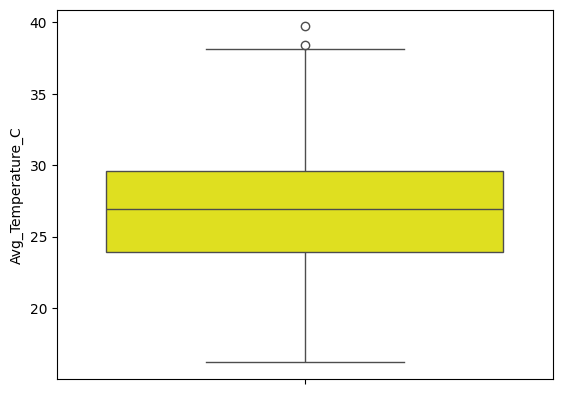

In [21]:
sns.boxplot(y='Avg_Temperature_C', data=df, color='yellow')

<Axes: ylabel='Soil_Moisture_pct'>

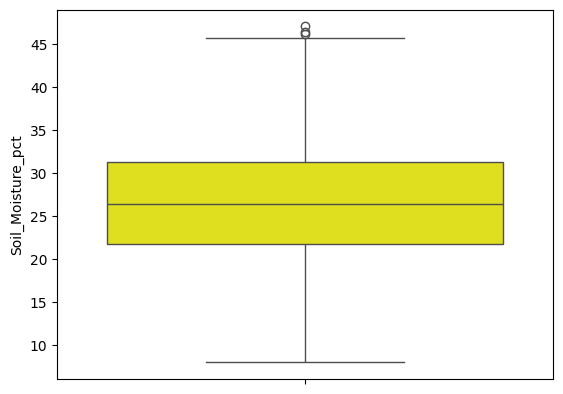

In [22]:
sns.boxplot(y='Soil_Moisture_pct', data=df, color='yellow')

<Axes: ylabel='Production_Tonnes'>

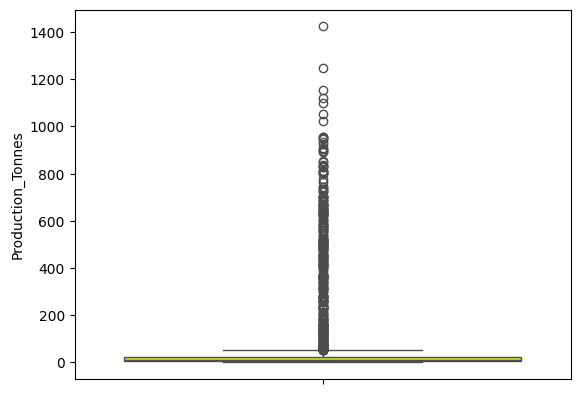

In [23]:
sns.boxplot(y='Production_Tonnes', data=df, color='yellow')

<Axes: ylabel='Revenue_INR'>

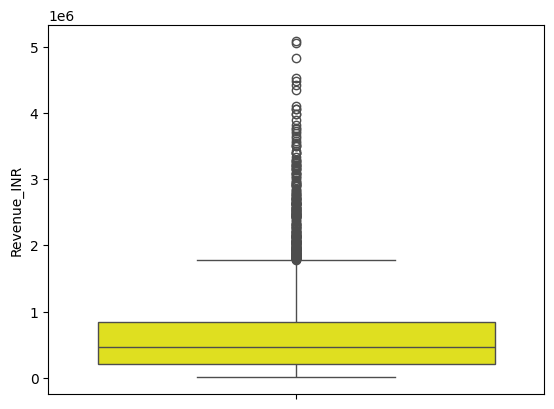

In [24]:
sns.boxplot(y='Revenue_INR', data=df, color='yellow')

<Axes: ylabel='Profit_INR'>

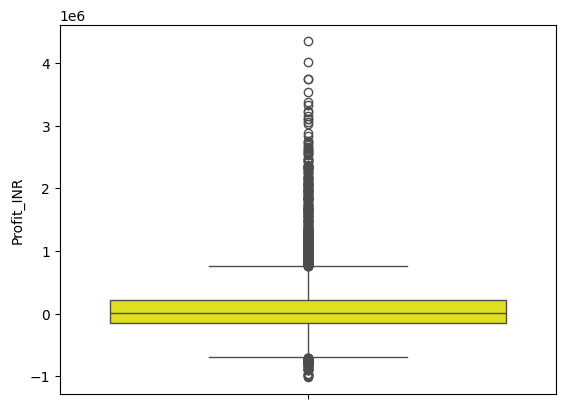

In [25]:
sns.boxplot(y='Profit_INR', data=df, color='yellow')

<Axes: ylabel='Water_Used_m3'>

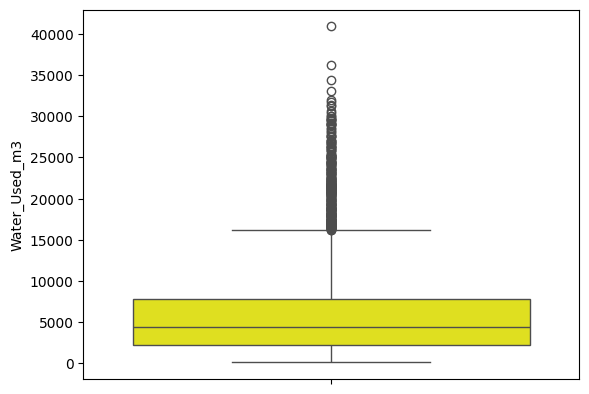

In [26]:
sns.boxplot(y='Water_Used_m3', data=df, color='yellow')

<Axes: ylabel='Water_Efficiency_t_per_1000m3'>

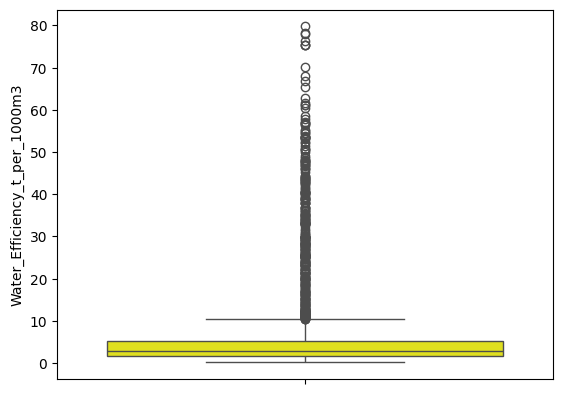

In [27]:
sns.boxplot(y='Water_Efficiency_t_per_1000m3', data=df, color='yellow')

<Axes: ylabel='Disease_Pest_Risk_pct'>

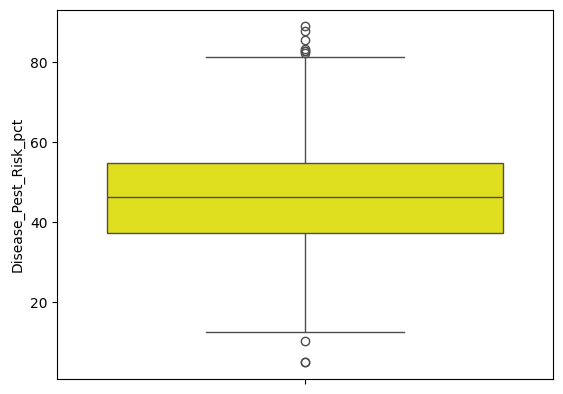

In [28]:
sns.boxplot(y='Disease_Pest_Risk_pct', data=df, color='yellow')

In [29]:
col = 'Yield_Tonnes_Ha'

Q1 = yield_df[col].quantile(0.25)
Q3 = yield_df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

yield_outliers = yield_df[
    (yield_df[col] < lower_bound) |
    (yield_df[col] > upper_bound)
]

print(f"Yield outliers: {len(yield_outliers)}")

Yield outliers: 302


<Axes: ylabel='Yield_Tonnes_Ha'>

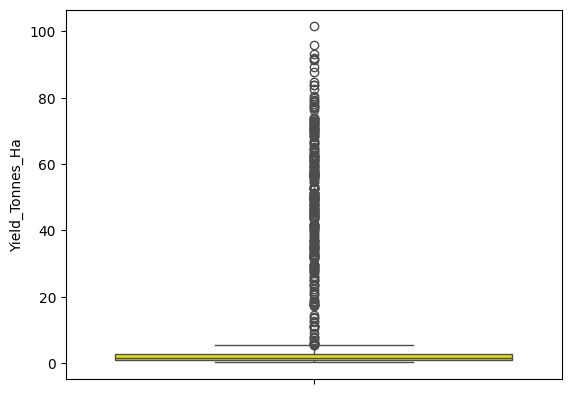

In [30]:
sns.boxplot(y='Yield_Tonnes_Ha', data=yield_df, color='yellow')

**<font color='red'>Analytical Statement:<br>Potential outliers were identified using boxplots. The observations of all above boxplots are based on the values lying beyond the boxplot whiskers. These observations were used for screening purposes only, and no outliers were removed because extreme values may represent plausible agricultural variations and the objective was to observe unusual values rather than remove observations without evidence of data-entry errors.
</font>**

> ### **4. FEATURE CREATION**

In [31]:
df[['Farm_Area_Hectares', 'Revenue_INR', 'Total_Cost_INR', 'Production_Tonnes']].eq(0).sum()

,0
Farm_Area_Hectares,0
Revenue_INR,0
Total_Cost_INR,0
Production_Tonnes,0


**<font color='yellow'>PROFIT MARGIN (%):</font>**

In [32]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

df[['Profit_INR', 'Revenue_INR', 'Profit_Margin_pct']]

,Profit_INR,Revenue_INR,Profit_Margin_pct
0,-11852,30810,-38.47
1,-451950,40401,"-1,118.66"
2,-124744,190466,-65.49
3,-95704,200740,-47.68
4,-144352,193607,-74.56
...,...,...,...
3995,-308169,54748,-562.89
3996,2071320,2567791,80.67
3997,-351711,433921,-81.05
3998,22256,176160,12.63


**<font color='yellow'>PROFIT PER HECTARE:</font>**

In [33]:
df['Profit_per_Hectare'] = (df['Profit_INR'] / df['Farm_Area_Hectares'])

df[['Profit_INR', 'Farm_Area_Hectares', 'Profit_per_Hectare']]

,Profit_INR,Farm_Area_Hectares,Profit_per_Hectare
0,-11852,0.53,"-22,362.26"
1,-451950,6.53,"-69,211.33"
2,-124744,4.86,"-25,667.49"
3,-95704,4.50,"-21,267.56"
4,-144352,4.21,"-34,287.89"
...,...,...,...
3995,-308169,4.72,"-65,290.04"
3996,2071320,8.77,"236,182.44"
3997,-351711,10.47,"-33,592.26"
3998,22256,1.73,"12,864.74"


**<font color='yellow'>REVENUE PER HECTARE:</font>**

In [34]:
df['Revenue_per_Hectare'] = (df['Revenue_INR'] / df['Farm_Area_Hectares'])

df[['Revenue_INR', 'Farm_Area_Hectares', 'Revenue_per_Hectare']]

,Revenue_INR,Farm_Area_Hectares,Revenue_per_Hectare
0,30810,0.53,"58,132.08"
1,40401,6.53,"6,186.98"
2,190466,4.86,"39,190.53"
3,200740,4.50,"44,608.89"
4,193607,4.21,"45,987.41"
...,...,...,...
3995,54748,4.72,"11,599.15"
3996,2567791,8.77,"292,792.59"
3997,433921,10.47,"41,444.22"
3998,176160,1.73,"101,826.59"


**<font color='yellow'>COST PER HECTARE:</font>**

In [35]:
df['Cost_per_Hectare'] = (df['Total_Cost_INR'] / df['Farm_Area_Hectares'])

df[['Total_Cost_INR', 'Farm_Area_Hectares', 'Cost_per_Hectare']]

,Total_Cost_INR,Farm_Area_Hectares,Cost_per_Hectare
0,42662,0.53,"80,494.34"
1,492351,6.53,"75,398.32"
2,315210,4.86,"64,858.02"
3,296444,4.50,"65,876.44"
4,337959,4.21,"80,275.30"
...,...,...,...
3995,362917,4.72,"76,889.19"
3996,496471,8.77,"56,610.15"
3997,785632,10.47,"75,036.49"
3998,153904,1.73,"88,961.85"


**<font color='yellow'>ROI (%):</font>**

In [36]:
df['ROI_pct'] = (df['Profit_INR'] / df['Total_Cost_INR']) * 100

df[['Profit_INR', 'Total_Cost_INR', 'ROI_pct']]

,Profit_INR,Total_Cost_INR,ROI_pct
0,-11852,42662,-27.78
1,-451950,492351,-91.79
2,-124744,315210,-39.57
3,-95704,296444,-32.28
4,-144352,337959,-42.71
...,...,...,...
3995,-308169,362917,-84.91
3996,2071320,496471,417.21
3997,-351711,785632,-44.77
3998,22256,153904,14.46


**<font color='yellow'>WATER USED PER TONNE:</font>**

In [37]:
df['Water_Used_per_Tonne'] = (df['Water_Used_m3'] / df['Production_Tonnes'])

df[['Water_Used_m3', 'Production_Tonnes', 'Water_Used_per_Tonne']]

,Water_Used_m3,Production_Tonnes,Water_Used_per_Tonne
0,237,1.30,182.31
1,4953,1.96,"2,527.04"
2,1275,2.53,503.95
3,3834,8.28,463.04
4,3287,9.30,353.44
...,...,...,...
3995,2016,2.41,836.51
3996,5351,24.12,221.85
3997,3392,6.49,522.65
3998,1220,2.34,521.37


> ### **5. SEASONAL PERFORMANCE ANALYSIS**<br>
Questions:<br>
1. Which season has the highest average yield?
2. Which season has the highest total production?
3. Which season has the highest average profit?
4. How do revenue and cost vary across seasons?
5. Which season has the best water efficiency?
6. Which season has the highest disease/pest risk?

> ### **5.1 Average Yield by Season**<br>
**TO FIND: Which season has the highest average yield?**

,Season,Yield_Tonnes_Ha
0,Kharif,5.64
1,Rabi,5.08
2,Zaid,4.67


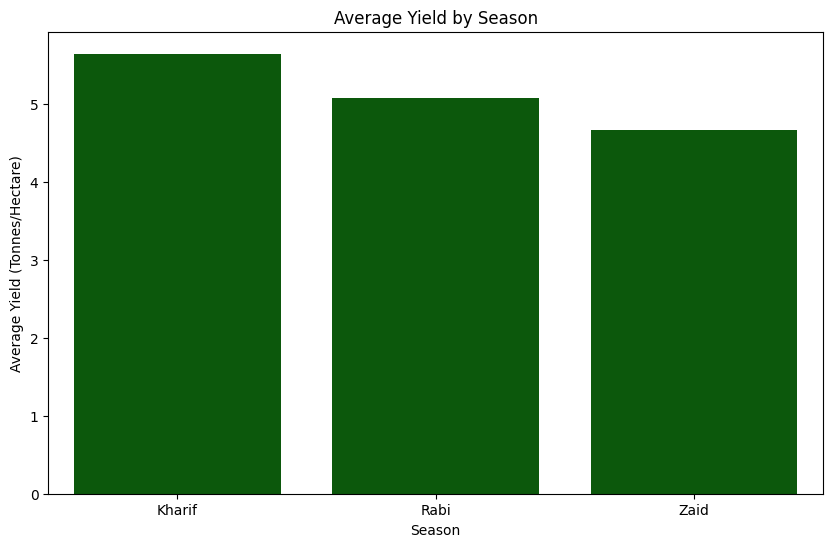

In [38]:
avg_yield_by_season = (yield_df.groupby('Season')['Yield_Tonnes_Ha'].mean().reset_index())

display(avg_yield_by_season)

# Visualization

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_yield_by_season, x='Season', y='Yield_Tonnes_Ha', color='darkgreen', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Hectare)')
plt.title('Average Yield by Season')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Yield by Season' bar chart indicates that the Kharif season has the highest average yield per hectare, followed by Rabi, and then Zaid, suggesting Kharif is generally the most productive season in terms of yield.</font>**

> ### **5.2 Total Production by Season**<br>
**TO FIND: Which season has the highest total production?**

,Season,Production_Tonnes
0,Kharif,"82,293.15"
1,Rabi,"66,430.09"
2,Zaid,"23,057.08"


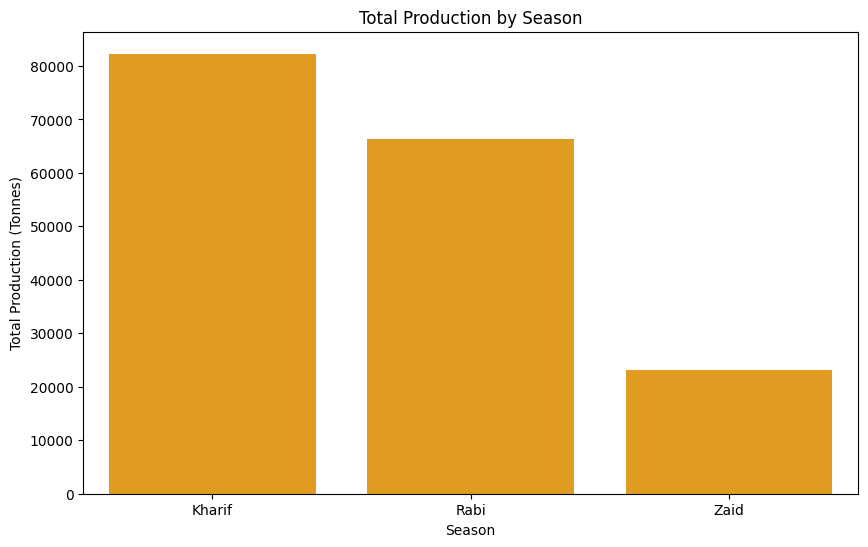

In [39]:
total_production_by_season = (yield_df.groupby('Season')['Production_Tonnes'].sum().reset_index())

display(total_production_by_season)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=total_production_by_season, x='Season', y='Production_Tonnes', color='orange', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Total Production (Tonnes)')
plt.title('Total Production by Season')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Total Production by Season' bar chart indicates that the Kharif season has the highest total production, followed by Rabi, and then Zaid, suggesting Kharif is the most productive season in terms of overall output.</font>**

> ### **5.3 Average Profit by Season**<br>
**TO FIND: Which season has the highest average profit?**

,Season,Profit_INR
0,Kharif,317838545
1,Rabi,141732983
2,Zaid,-15662922


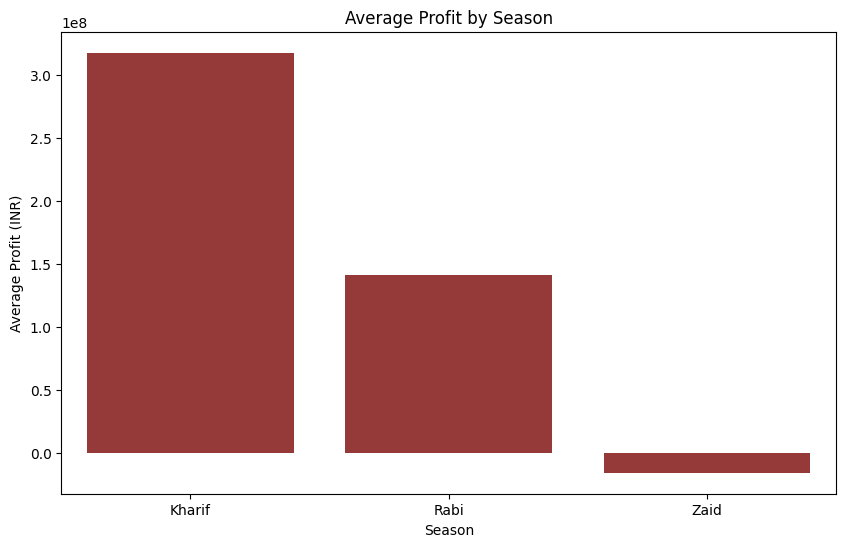

In [40]:
avg_profit_by_season = (yield_df.groupby('Season')['Profit_INR'].sum().reset_index())

display(avg_profit_by_season)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_profit_by_season, x='Season', y='Profit_INR', color='brown', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.title('Average Profit by Season')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Profit by Season' bar chart indicates that the Kharif season has the highest average profit, followed by Rabi, while the Zaid season shows an overall loss.</font>**

> ### **5.4 Revenue vs Cost across Seasons**<br>
**TO FIND: How do revenue and cost vary across seasons?**

,Season,Revenue_INR,Total_Cost_INR
0,Kharif,1264369200,946080042
1,Rabi,978682881,836012113
2,Zaid,308388111,323122177


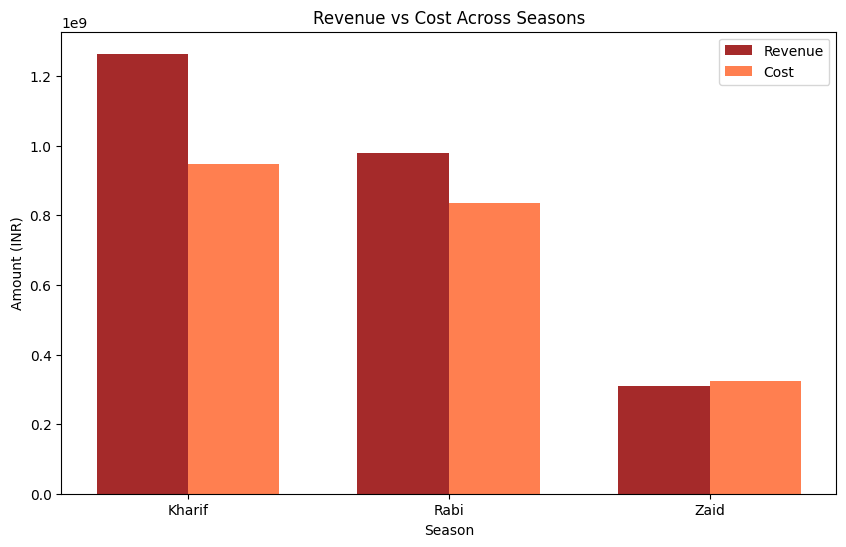

In [41]:
season_financials = df.groupby('Season')[['Revenue_INR', 'Total_Cost_INR']].sum().reset_index()

display(season_financials)

# Visualization:

plt.figure(figsize=(10, 6))

x = np.arange(len(season_financials['Season']))
width = 0.35
0
plt.bar(x - width/2, season_financials['Revenue_INR'], width, label='Revenue', color='brown')

plt.bar(x + width/2, season_financials['Total_Cost_INR'], width,label='Cost', color='coral')

plt.xticks(x, season_financials['Season'])
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.title('Revenue vs Cost Across Seasons')
plt.legend()
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Revenue vs Cost Across Seasons' bar chart reveals that the Kharif season generates significantly more revenue than its costs, indicating high profitability. The Rabi season also shows a positive margin with revenue exceeding costs. In contrast, the Zaid season demonstrates higher costs than revenue, suggesting it operates at a loss.</font>**

> ### **5.5 Water Efficiency by Season**<br>
**TO FIND: Which season has the best water efficiency?**

,Season,Water_Efficiency_t_per_1000m3
0,Kharif,"10,466.47"
1,Rabi,"8,321.79"
2,Zaid,"2,615.70"


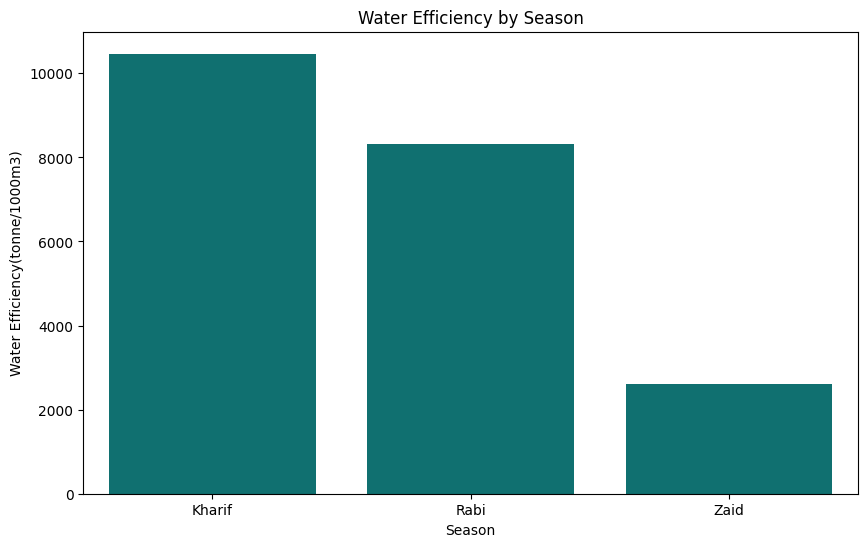

In [42]:
water_efficiency_by_season = (yield_df.groupby('Season')['Water_Efficiency_t_per_1000m3'].sum().reset_index())

display(water_efficiency_by_season)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=water_efficiency_by_season, x='Season', y='Water_Efficiency_t_per_1000m3', color='teal', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Water Efficiency(tonne/1000m3)')
plt.title('Water Efficiency by Season')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Water Efficiency by Season' bar chart indicates that the Kharif season has the highest water efficiency, producing the most tonnes per 1000m³ of water, followed by Rabi, and then Zaid. This suggests that Kharif is the most water-efficient season for agriculture.</font>**

> ### **5.6 Disease/Pest Risk by Season**<br>
**TO FIND: Which season has the highest disease/pest risk?**

,Season,Disease_Pest_Risk_pct
0,Kharif,54.47
1,Rabi,40.48
2,Zaid,38.22


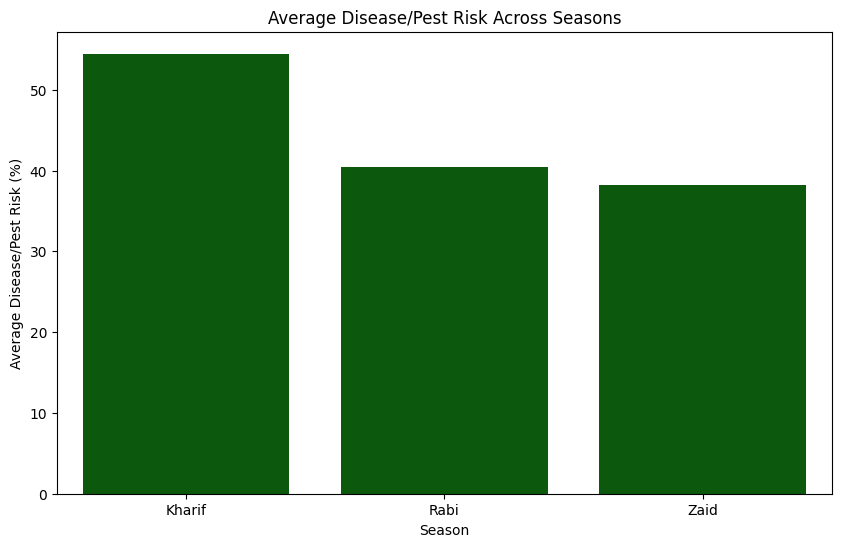

In [43]:
disease_pest_risk_by_season = (df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reset_index())

display(disease_pest_risk_by_season)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=disease_pest_risk_by_season, x='Season', y='Disease_Pest_Risk_pct', color='darkgreen', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Average Disease/Pest Risk (%)')
plt.title('Average Disease/Pest Risk Across Seasons')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Disease/Pest Risk Across Seasons' bar chart indicates that the Kharif season has the highest average disease and pest risk, followed by Rabi, and then Zaid. This suggests that the Kharif season is most susceptible to disease and pest outbreaks.</font>**

> ### **6. CROP PERFORMANCE ANALYSIS**<br>
Questions:<br>
1. Which crops perform best in each season?
2. Which crop has the highest average yield?
3. Which crop generates the highest total/average profit?
4. How do revenue and cost vary across crops?
5. Which crop requires the most water to produce 1 tonne?
6. Which crop uses the most water overall?
7. How does crop production vary across states, and which crops contribute most to state-level production?


> ### **6.1. Average Crop Yield by Season & Average Crop Profit by Season:**<br>
**TO FIND: Which crops perform best in each season?**

In [44]:
# Average Crop Yield by Season

season_crop_yield = (yield_df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].mean().reset_index().sort_values(['Season', 'Yield_Tonnes_Ha'],ascending=[True, False]))

season_crop_yield

,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.46
3,Kharif,Maize,2.97
5,Kharif,Rice,2.71
7,Kharif,Wheat,2.26
0,Kharif,Chilli,1.73
2,Kharif,Groundnut,1.48
1,Kharif,Cotton,1.37
4,Kharif,Pulses,1.04
14,Rabi,Sugarcane,43.94
11,Rabi,Maize,2.61


In [45]:
# Best Crop by Yield

best_crop_by_yield = (season_crop_yield.loc[season_crop_yield.groupby('Season')['Yield_Tonnes_Ha'].idxmax()].sort_values('Season').reset_index(drop=True))

best_crop_by_yield

,Season,Crop,Yield_Tonnes_Ha
0,Kharif,Sugarcane,53.46
1,Rabi,Sugarcane,43.94
2,Zaid,Sugarcane,38.42


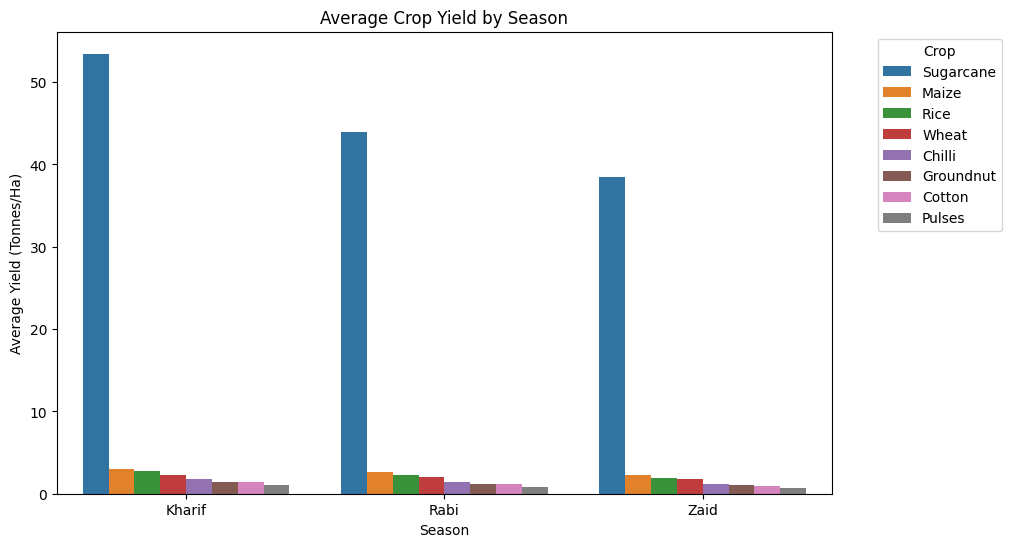

In [46]:
# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=season_crop_yield, x='Season', y='Yield_Tonnes_Ha', hue='Crop',errorbar=None)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Crop Yield by Season' bar chart clearly demonstrates that Sugarcane consistently achieves the highest average yield across all three seasons (Kharif, Rabi, and Zaid). Other crops show significantly lower yields compared to Sugarcane, indicating its strong productivity regardless of the season.</font>**

In [47]:
# Average Crop Profit by Season

season_crop_profit = (df.groupby(['Season', 'Crop'])['Profit_INR'].mean().reset_index().sort_values(['Season', 'Profit_INR'],ascending=[True, False]))

season_crop_profit

,Season,Crop,Profit_INR
6,Kharif,Sugarcane,"1,000,790.81"
0,Kharif,Chilli,"954,380.42"
1,Kharif,Cotton,"216,999.55"
2,Kharif,Groundnut,"108,265.44"
4,Kharif,Pulses,"43,338.90"
3,Kharif,Maize,"-39,332.67"
5,Kharif,Rice,"-64,903.40"
7,Kharif,Wheat,"-105,871.87"
14,Rabi,Sugarcane,"731,612.86"
8,Rabi,Chilli,"638,572.50"


In [48]:
# Best Crop by Profit

best_crop_by_profit = (season_crop_profit.loc[season_crop_profit.groupby('Season')['Profit_INR'].idxmax()].sort_values('Season').reset_index(drop=True))

best_crop_by_profit

,Season,Crop,Profit_INR
0,Kharif,Sugarcane,"1,000,790.81"
1,Rabi,Sugarcane,"731,612.86"
2,Zaid,Sugarcane,"583,635.80"


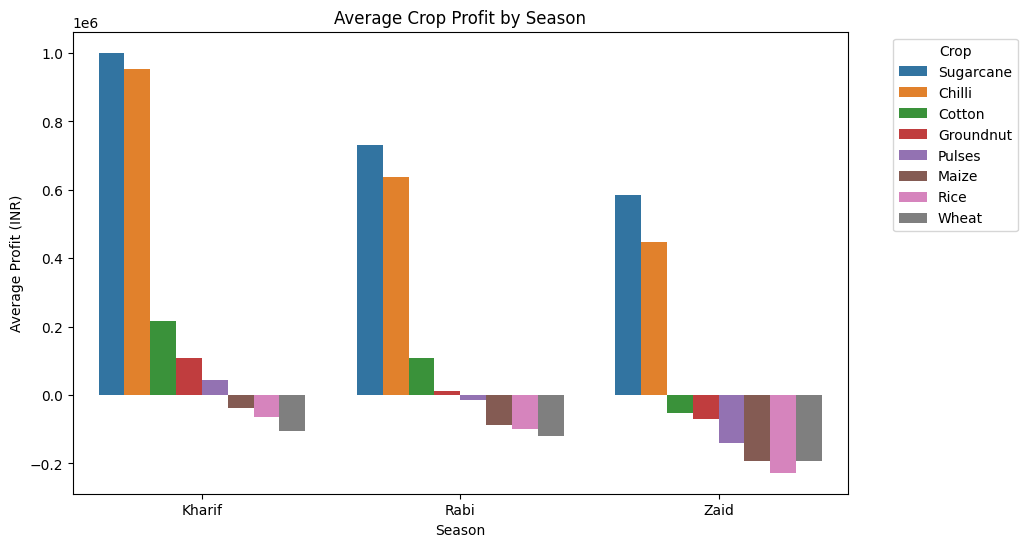

In [49]:
# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=season_crop_profit, x='Season', y='Profit_INR', hue='Crop', errorbar=None)

plt.title('Average Crop Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Crop Profit by Season' bar chart indicates that Sugarcane consistently generates the highest average profit across all three seasons (Kharif, Rabi, and Zaid). Crops like Chilli also show good profitability in Kharif and Rabi. Conversely, Maize, Rice, and Wheat frequently show negative average profits, especially in the Zaid season, suggesting they are less profitable or incur losses during these periods.</font>**

In [50]:
# Compare Crop Performance by Yield and Profit Across Seasons

crop_performance = pd.merge(best_crop_by_yield, best_crop_by_profit, on=['Season', 'Crop'], how='outer')

crop_performance

,Season,Crop,Yield_Tonnes_Ha,Profit_INR
0,Kharif,Sugarcane,53.46,"1,000,790.81"
1,Rabi,Sugarcane,43.94,"731,612.86"
2,Zaid,Sugarcane,38.42,"583,635.80"


**<font color='red'>Analytical Statement:<br>The 'Crop Performance by Yield and Profit Across Seasons' data clearly indicates that Sugarcane is the top-performing crop, consistently achieving the highest yield and profit across all three seasons (Kharif, Rabi, and Zaid). This highlights Sugarcane's robust performance and profitability regardless of the agricultural season.</font>**

>### **6.2 Average Yield by Crop**
**TO FIND: Which crop has the highest average yield?**

,Crop,Yield_Tonnes_Ha
0,Sugarcane,46.94
1,Maize,2.72
2,Rice,2.44
3,Wheat,2.11
4,Chilli,1.54
5,Groundnut,1.32
6,Cotton,1.23
7,Pulses,0.92


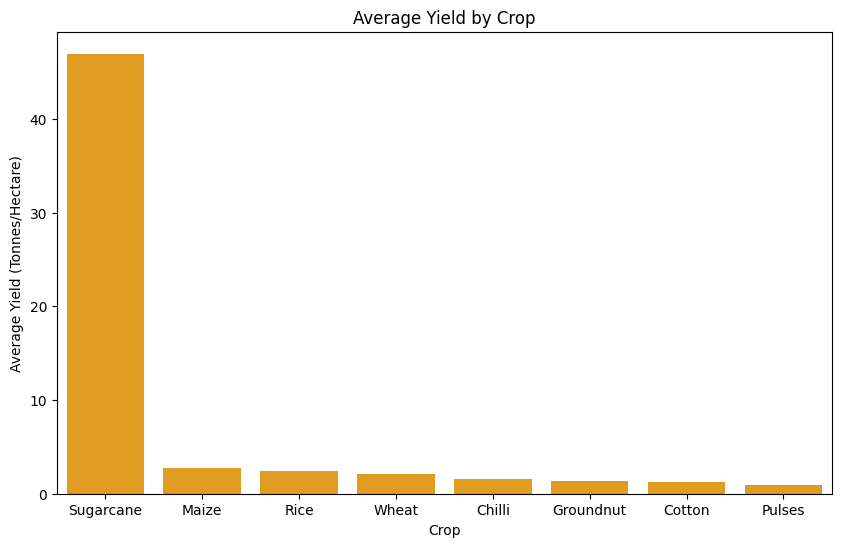

In [51]:
avg_yield_by_crop = (yield_df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False).reset_index())

display(avg_yield_by_crop)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_yield_by_crop, x='Crop', y='Yield_Tonnes_Ha', color='orange', errorbar=None)
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Hectare)')
plt.title('Average Yield by Crop')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Yield by Crop' bar chart clearly indicates that Sugarcane has the highest average yield per hectare, significantly outperforming all other crops. This suggests Sugarcane is the most productive crop in terms of yield.</font>**

>### **6.3 Average Profit by Crop**
**TO FIND: Which crop generates the highest total/average profit?**

,Crop,Profit_INR
0,Chilli,309361877
1,Sugarcane,249242336
2,Cotton,63269833
3,Groundnut,19019843
4,Pulses,-2102074
5,Maize,-46272058
6,Rice,-70527318
7,Wheat,-75766579


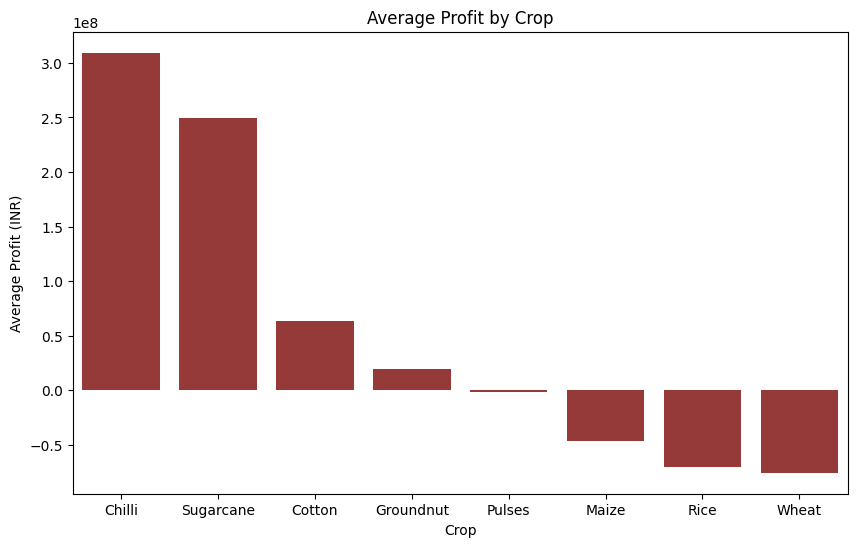

In [52]:
avg_profit_by_crop = (df.groupby('Crop')['Profit_INR'].sum().sort_values(ascending=False).reset_index())

display(avg_profit_by_crop)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_profit_by_crop, x='Crop', y='Profit_INR', color='brown', errorbar=None)
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.title('Average Profit by Crop')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Profit by Crop' bar chart clearly shows that Chilli and Sugarcane are the most profitable crops, generating significant total profits. In contrast, Wheat, Rice, Maize, and Pulses appear to be unprofitable, as indicated by their negative total profit values.</font>**

>### **6.4 Revenue vs Cost across Crops**
**TO FIND: How do revenue and cost vary across crops?**

,Crop,Revenue_INR,Total_Cost_INR
0,Chilli,526032218,216670341
1,Cotton,324826926,261557093
2,Groundnut,230204651,211184808
3,Maize,251844463,298116521
4,Pulses,262119070,264221144
5,Rice,292294529,362821847
6,Sugarcane,418453935,169211599
7,Wheat,245664400,321430979


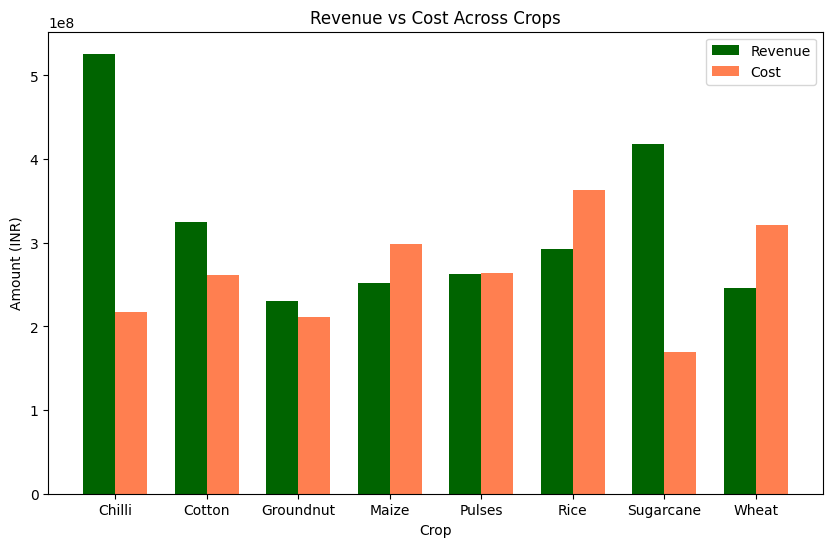

In [53]:
crop_financials = df.groupby('Crop')[['Revenue_INR', 'Total_Cost_INR']].sum().reset_index()

display(crop_financials)

# Visualization:

plt.figure(figsize=(10, 6))

x = np.arange(len(crop_financials['Crop']))
width = 0.35

plt.bar(x - width/2, crop_financials['Revenue_INR'], width, label='Revenue', color='darkgreen')

plt.bar(x + width/2, crop_financials['Total_Cost_INR'], width,label='Cost', color='coral')

plt.xticks(x, crop_financials['Crop'])
plt.xlabel('Crop')
plt.ylabel('Amount (INR)')
plt.title('Revenue vs Cost Across Crops')
plt.legend()
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Revenue vs Cost Across Crops' bar chart clearly shows that Chilli and Sugarcane have substantially higher revenues compared to their costs, indicating strong profitability. Cotton and Groundnut also show revenues exceeding costs, suggesting they are profitable crops. In contrast, Maize, Pulses, Rice, and Wheat all demonstrate costs that are higher than their revenues, highlighting their unprofitability within this dataset.</font>**

>### **6.5 Average Water Used Per Tonne by Crop**
**TO FIND: Which crop requires the most water to produce 1 tonne?**

,Crop,Water_Used_per_Tonne
0,Rice,932.49
1,Cotton,768.93
2,Chilli,593.59
3,Pulses,518.16
4,Groundnut,504.88
5,Wheat,352.97
6,Maize,303.68
7,Sugarcane,60.46


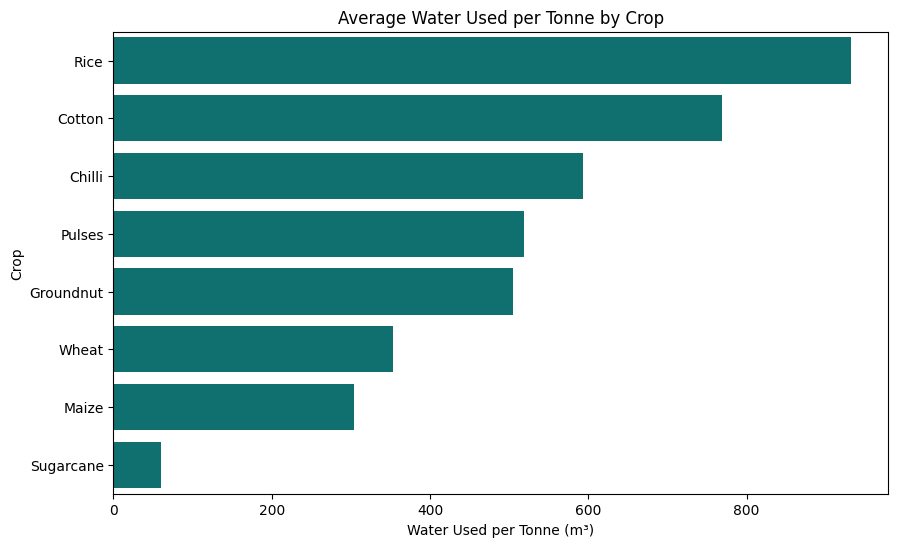

In [54]:
avg_water_used_by_crop = (df.groupby('Crop')['Water_Used_per_Tonne'].mean().sort_values(ascending=False).reset_index())

display(avg_water_used_by_crop)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_water_used_by_crop, x='Water_Used_per_Tonne', y='Crop', errorbar=None, color='teal')

plt.title('Average Water Used per Tonne by Crop')
plt.xlabel('Water Used per Tonne (m³)')
plt.ylabel('Crop')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Water Used per Tonne by Crop' bar chart reveals that Rice and Cotton require the most water per tonne of production, indicating lower water efficiency for these crops. In stark contrast, Sugarcane requires significantly less water per tonne, highlighting its high water efficiency.</font>**

>### **6.6 Overall Water Used by Crop**
**TO FIND: Which crop uses the most water overall?**

,Crop,Water_Used_m3
0,Sugarcane,"13,897.70"
1,Rice,"10,920.22"
2,Cotton,"5,410.86"
3,Chilli,"4,577.47"
4,Maize,"4,377.78"
5,Wheat,"4,054.40"
6,Groundnut,"3,459.54"
7,Pulses,"2,833.67"


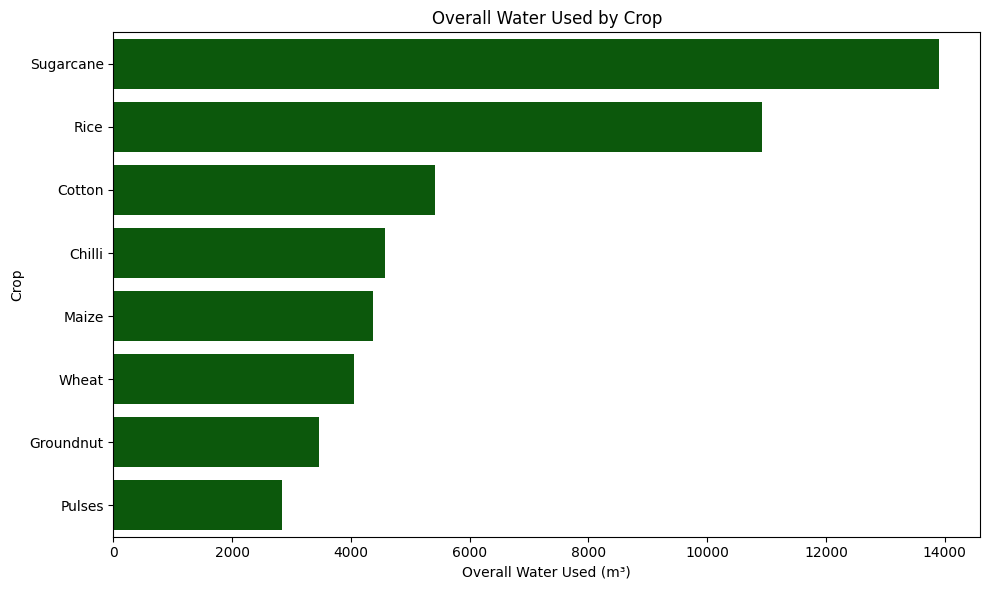

In [55]:
overall_water_used_by_crop = (df.groupby('Crop')['Water_Used_m3'].mean().sort_values(ascending=False).reset_index())

display(overall_water_used_by_crop)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=overall_water_used_by_crop, x='Water_Used_m3', y='Crop',errorbar=None, color='darkgreen')

plt.title('Overall Water Used by Crop')
plt.xlabel('Overall Water Used (m³)')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Overall Water Used by Crop' bar chart indicates that Sugarcane and Rice are the crops that consume the most water in terms of total volume. In contrast, Pulses, Groundnut, Wheat, and Maize require significantly less overall water, suggesting they are less water-intensive crops in terms of total usage across the dataset.</font>**

>### **6.7 State-wise Crop Production Analysis**
**TO FIND: How does crop production vary across states, and which crops contribute most to state-level production?**

,State,Crop,Production_Tonnes
0,Punjab,Sugarcane,"18,607.96"
1,Gujarat,Sugarcane,"17,188.34"
2,Karnataka,Sugarcane,"16,884.62"
3,Maharashtra,Sugarcane,"15,707.38"
4,Tamil Nadu,Sugarcane,"13,528.01"
5,Telangana,Sugarcane,"13,019.74"
6,Andhra Pradesh,Sugarcane,"12,461.35"
7,Madhya Pradesh,Sugarcane,"12,288.57"


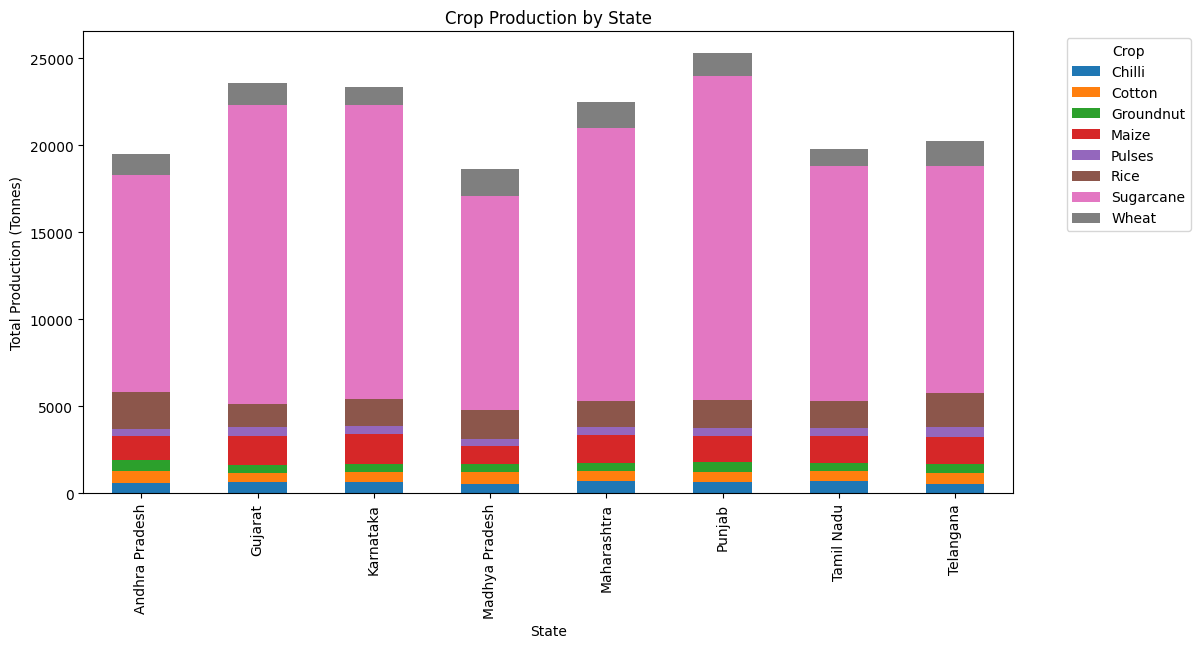

In [56]:
# Total Production by State and Crop
state_crop_production = (df.groupby(['State', 'Crop'])['Production_Tonnes'].sum().reset_index())

# Highest-producing crop in each state
top_crop_by_state = (state_crop_production.loc[state_crop_production.groupby('State')['Production_Tonnes'].idxmax()].sort_values('Production_Tonnes', ascending=False).reset_index(drop=True))

display(top_crop_by_state)

# Prepare data for stacked column chart
state_crop_chart = (state_crop_production.pivot(index='State', columns='Crop', values='Production_Tonnes').fillna(0))

# Create stacked column chart
state_crop_chart.plot(kind='bar', stacked=True,figsize=(12, 6))

plt.title('Crop Production by State')
plt.xlabel('State')
plt.ylabel('Total Production (Tonnes)')
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1),loc='upper left')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Crop Production by State' stacked bar chart clearly illustrates that Sugarcane is the dominant crop, contributing the highest production volume across all listed states. This indicates that state-level agricultural output is heavily influenced by Sugarcane cultivation, making it the top-performing crop in terms of total production for each state.</font>**

> ### **7. ENVIRONMENTAL FACTOR ANALYSIS**<br>
Questions:<br>
1. How does rainfall vary across seasons? Is it associated with yield?
2. How does average temperature differ across seasons? Is it associated with yield?
3. How does soil moisture vary across seasons? Is it associated with yield?
4. Is humidity associated with yield?
5. Is disease/pest risk associated with yield?


> ### **7.1 Rainfall Analysis: Seasonal Variation and Association with Yield**
**TO FIND: How does rainfall vary across seasons? Is it associated with yield?**

,Season,Rainfall_mm
0,Kharif,852.11
1,Rabi,435.93
2,Zaid,299.34


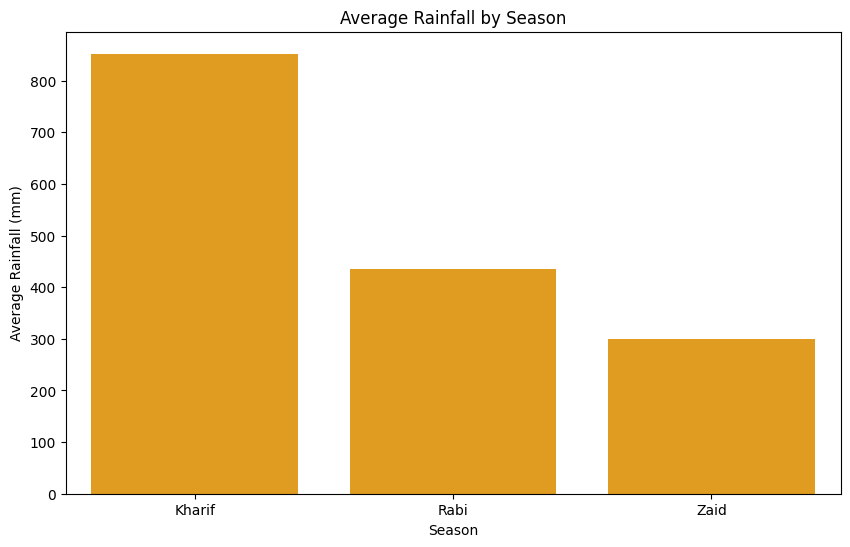

In [57]:
avg_rainfall_by_season = (df.groupby('Season')['Rainfall_mm'].mean().sort_values(ascending=False).reset_index())

display(avg_rainfall_by_season)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_rainfall_by_season, x='Season', y='Rainfall_mm', color='orange', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')
plt.title('Average Rainfall by Season')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Rainfall by Season' bar chart indicates that the Kharif season receives the highest average rainfall, followed by the Rabi season, and then the Zaid season, which experiences the lowest average rainfall. This suggests that Kharif is the wettest agricultural season.</font>**

In [58]:
correlation_rainfall_yield = yield_df['Rainfall_mm'].corr(yield_df['Yield_Tonnes_Ha'])

print(f'Pearson Correlation between Rainfall and Yield: {correlation_rainfall_yield:.2f}')

Pearson Correlation between Rainfall and Yield: 0.03


**<font color='red'>Analytical Statement:<br>The Pearson Correlation coefficient between Rainfall and Yield is 0.03. This indicates a very weak positive linear relationship, suggesting that rainfall, in this dataset, has a negligible direct association with agricultural yield.</font>**

> ### **7.2 Temperature Analysis: Seasonal Variation and Association with Yield**
**TO FIND: How does average temperature differ across seasons? Is it associated with yield?**

,Season,Avg_Temperature_C
0,Zaid,31.04
1,Kharif,28.45
2,Rabi,23.49


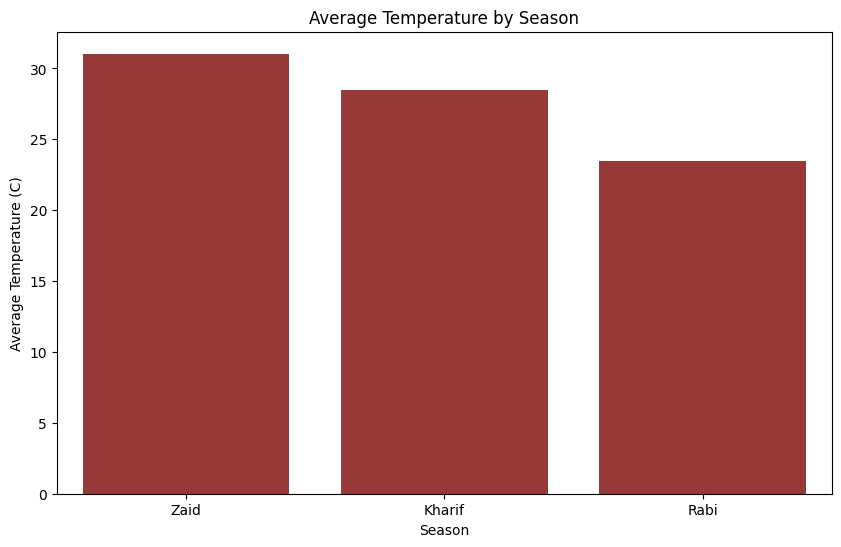

In [59]:
avg_temp_by_season = (df.groupby('Season')['Avg_Temperature_C'].mean().sort_values(ascending=False).reset_index())

display(avg_temp_by_season)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_temp_by_season, x='Season', y='Avg_Temperature_C', color='brown', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Average Temperature (C)')
plt.title('Average Temperature by Season')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Temperature by Season' bar chart indicates that the Zaid season has the highest average temperature, followed by the Kharif season, and then the Rabi season, which experiences the lowest average temperature. This suggests that Zaid is the hottest agricultural season.</font>**

In [60]:
correlation_temp_yield = yield_df['Avg_Temperature_C'].corr(yield_df['Yield_Tonnes_Ha'])

print(f'Pearson Correlation between Temperature and Yield: {correlation_temp_yield:.2f}')

Pearson Correlation between Temperature and Yield: 0.01


**<font color='red'>Analytical Statement:<br>The Pearson Correlation coefficient between Temperature and Yield is 0.01. This indicates an extremely weak positive linear relationship, suggesting that average temperature, in this dataset, has a negligible direct association with agricultural yield.</font>**

> ### **7.3 Soil Moisture Analysis: Seasonal Variation and Association with Yield**
**TO FIND: How does soil moisture vary across seasons? Is it associated with yield?**

,Season,Soil_Moisture_pct
0,Kharif,31.20
1,Rabi,24.05
2,Zaid,19.17


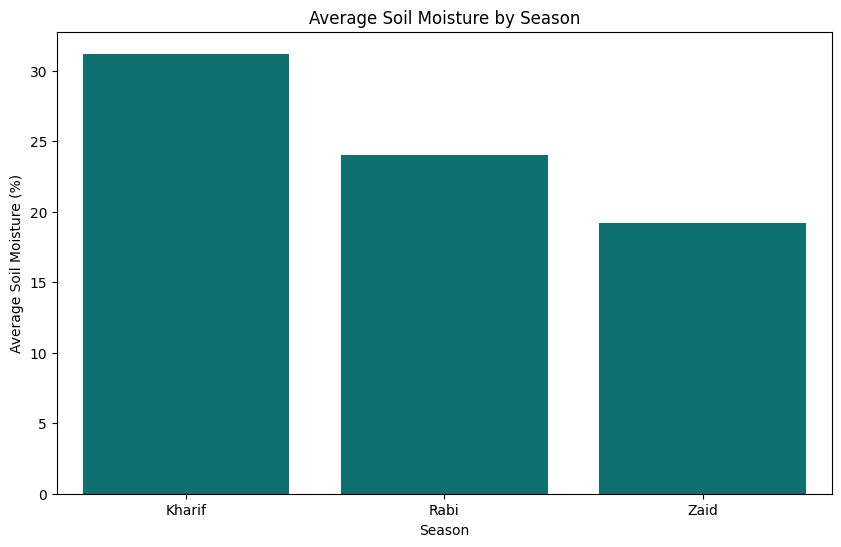

In [61]:
avg_soil_moisture_by_season = (df.groupby('Season')['Soil_Moisture_pct'].mean().sort_values(ascending=False).reset_index())

display(avg_soil_moisture_by_season)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_soil_moisture_by_season, x='Season', y='Soil_Moisture_pct', color='teal', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Average Soil Moisture (%)')
plt.title('Average Soil Moisture by Season')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Soil Moisture by Season' bar chart indicates that the Kharif season has the highest average soil moisture, followed by the Rabi season, and then the Zaid season, which experiences the lowest average soil moisture. This pattern aligns with the rainfall distribution, suggesting that higher rainfall contributes to increased soil moisture during the Kharif season.</font>**

In [62]:
correlation_soil_moisture_yield = yield_df['Soil_Moisture_pct'].corr(yield_df['Yield_Tonnes_Ha'])

print(f'Pearson Correlation between Soil Moisture and Yield: {correlation_soil_moisture_yield:.2f}')

Pearson Correlation between Soil Moisture and Yield: 0.01


**<font color='red'>Analytical Statement:<br>The Pearson Correlation coefficient between Soil Moisture and Yield is 0.01. This indicates an extremely weak positive linear relationship, suggesting that soil moisture, in this dataset, has a negligible direct association with agricultural yield.</font>**

> ### **7.4 Humidity VS Yield**
**TO FIND: Is humidity associated with yield?**

In [63]:
correlation_humidity_yield = yield_df['Humidity_pct'].corr(yield_df['Yield_Tonnes_Ha'])

print(f'Pearson Correlation between Humidity and Yield: {correlation_humidity_yield:.2f}')

Pearson Correlation between Humidity and Yield: 0.01


**<font color='red'>Analytical Statement:<br>The Pearson Correlation coefficient between Humidity and Yield is 0.01. This indicates an extremely weak positive linear relationship, suggesting that humidity, in this dataset, has a negligible direct association with agricultural yield.</font>**

> ### **7.5 Disease/Pest Risk vs Yield**
**TO FIND: Is disease/pest risk associated with yield?**

In [64]:
correlation_disease_pest_yield = yield_df['Disease_Pest_Risk_pct'].corr(yield_df['Yield_Tonnes_Ha'])

print(f'Pearson Correlation between Disease/Pest Risk and Yield: {correlation_disease_pest_yield:.2f}')

Pearson Correlation between Disease/Pest Risk and Yield: 0.01


**<font color='red'>Analytical Statement:<br>The Pearson Correlation coefficient between Disease/Pest Risk and Yield is 0.01. This indicates an extremely weak positive linear relationship, suggesting that disease/pest risk, in this dataset, has a negligible direct association with agricultural yield.</font>**

> ### **8. FARMING PRACTICE ANALYSIS**<br>

Questions:<br>
1. Which irrigation method provides better water efficiency, and how does yield vary across irrigation methods?
2. Is Water Efficiency associated with Yield?
3. Is seed quality associated with higher yield?
4. How does fertilizer usage vary across seasons and crops? Is it associated with yield?
5. How does pesticide usage vary across seasons and crops? Is it associated with yield?
6. How does nutrient usage vary across seasons and crops? Is it associated with yield?


> ### **8.1 Irrigation Method Analysis: Water Efficiency and Yield Comparison**
**TO FIND: Which irrigation method provides better water efficiency, and how does yield vary across irrigation methods?**

,Irrigation_Method,Water_Efficiency_t_per_1000m3
0,Rainfed,7.56
1,Drip,6.27
2,Sprinkler,4.67
3,Flood,3.44


,Irrigation_Method,Yield_Tonnes_Ha
0,Drip,6.62
1,Sprinkler,5.19
2,Flood,4.90
3,Rainfed,4.61


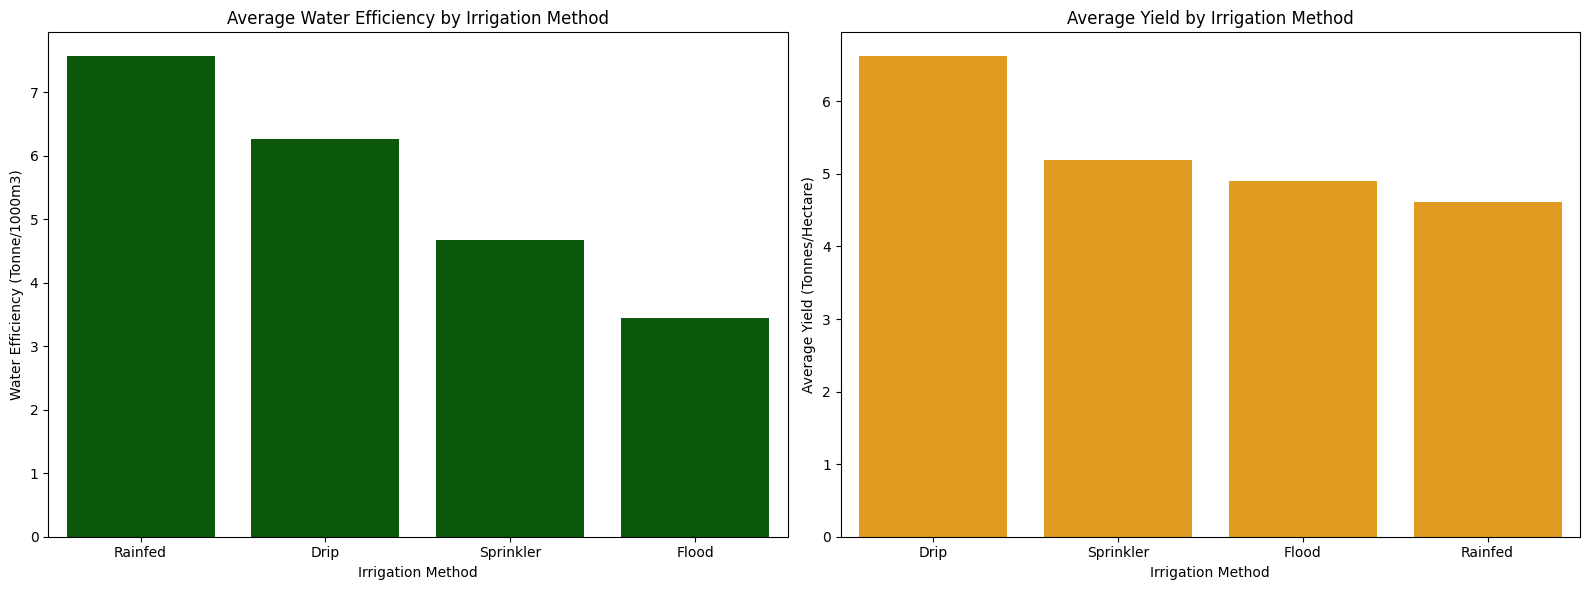

In [65]:
# Average Water Efficiency by Irrigation Method

avg_water_efficiency_by_irrigation = (df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False).reset_index())

display(avg_water_efficiency_by_irrigation)

# Average Yield by Irrigation Method

avg_yield_by_irrigation = (yield_df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False).reset_index())

display(avg_yield_by_irrigation)

# Visualization:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Water Efficiency by Irrigation Method
sns.barplot(data=avg_water_efficiency_by_irrigation, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', color='darkgreen', errorbar=None, ax=axes[0])
axes[0].set_xlabel('Irrigation Method')
axes[0].set_ylabel('Water Efficiency (Tonne/1000m3)')
axes[0].set_title('Average Water Efficiency by Irrigation Method')


# Plot 2: Average Yield by Irrigation Method
sns.barplot(data=avg_yield_by_irrigation, x='Irrigation_Method', y='Yield_Tonnes_Ha', color='orange', errorbar=None, ax=axes[1])
axes[1].set_xlabel('Irrigation Method')
axes[1].set_ylabel('Average Yield (Tonnes/Hectare)')
axes[1].set_title('Average Yield by Irrigation Method')

plt.tight_layout()
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Water Efficiency by Irrigation Method' chart shows that 'Rainfed' agriculture has the highest water efficiency (7.56 tonnes/1000m³), followed by 'Drip' (6.27 tonnes/1000m³). However, the 'Average Yield by Irrigation Method' chart indicates that 'Drip' irrigation leads to the highest average yield (6.62 Tonnes/Hectare), suggesting it is the most effective method for maximizing yield, even though 'Rainfed' is more water-efficient.</font>**

> ### **8.2 Water Efficiency vs Yield**
**TO FIND: Is Water Efficiency associated with Yield?**

In [66]:
correlation_water_efficiency_yield = yield_df['Water_Efficiency_t_per_1000m3'].corr(yield_df['Yield_Tonnes_Ha'])

print(f'Correlation between Water Efficiency and Yield: {correlation_water_efficiency_yield:.2f}')

Correlation between Water Efficiency and Yield: 0.92


**<font color='red'>Analytical Statement:<br>The Pearson Correlation coefficient between Water Efficiency and Yield is 0.92. This indicates a very strong positive linear relationship, suggesting that as water efficiency increases, agricultural yield also tends to increase significantly.</font>**

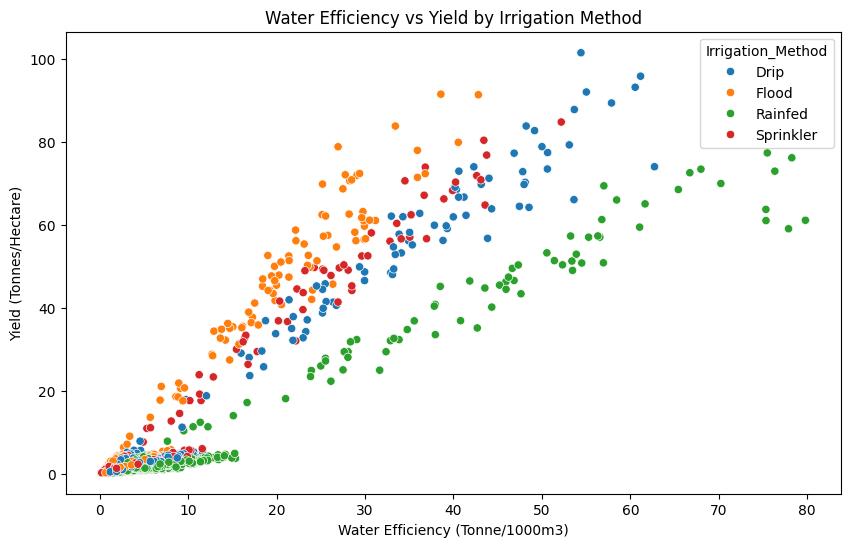

In [67]:
# Visualization:

plt.figure(figsize=(10, 6))

sns.scatterplot(data=yield_df, x='Water_Efficiency_t_per_1000m3', y='Yield_Tonnes_Ha', hue='Irrigation_Method')
plt.xlabel('Water Efficiency (Tonne/1000m3)')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.title('Water Efficiency vs Yield by Irrigation Method')
plt.show()

**<font color='red'>Analytical Statement:<br>The scatter plot of 'Water Efficiency vs Yield by Irrigation Method' visually confirms a strong positive correlation between water efficiency and yield. It shows that higher water efficiency generally leads to higher yields, and notably, 'Drip' irrigation appears to achieve both high water efficiency and high yields compared to other methods, while 'Rainfed' agriculture, despite having some high water efficiency points, shows a wider spread in yield.</font>**

> ### **8.3 Seed Quality vs Yield**
**TO FIND: Is seed quality associated with higher yield?**

In [68]:
correlation_seed_quality_yield = yield_df['Seed_Quality_Score'].corr(yield_df['Yield_Tonnes_Ha'])

print(f'Correlation between Water Seed Quality and Yield: {correlation_seed_quality_yield:.2f}')

Correlation between Water Seed Quality and Yield: -0.01


**<font color='red'>Analytical Statement:<br>The Pearson Correlation coefficient between Seed Quality and Yield is -0.01. This indicates an extremely weak negative linear relationship, suggesting that seed quality, in this dataset, has a negligible direct association with agricultural yield.</font>**

> ### **8.4 Fertilizer Analysis: Seasonal Variation, Crop Variation and Association with Yield**
**TO FIND: How does fertilizer usage vary across seasons and crops? Is it associated with yield?**

,Season,Fertilizer_kg_ha
0,Kharif,187.08
1,Rabi,185.41
2,Zaid,184.64


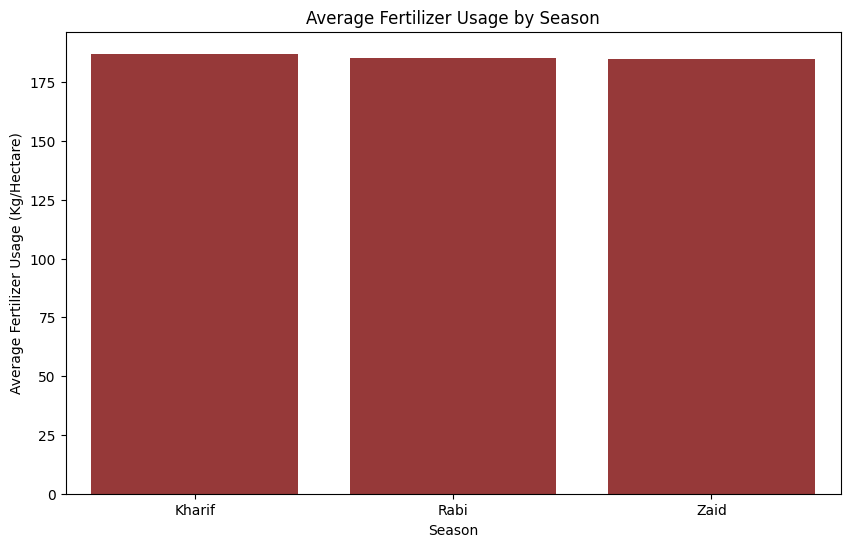

In [69]:
# Seasonal Variation

avg_fertilizer_usage_by_season = (df.groupby('Season')['Fertilizer_kg_ha'].mean().sort_values(ascending=False).reset_index())

display(avg_fertilizer_usage_by_season)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_fertilizer_usage_by_season, x='Season', y='Fertilizer_kg_ha', color='brown', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Average Fertilizer Usage (Kg/Hectare)')
plt.title('Average Fertilizer Usage by Season')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Fertilizer Usage by Season' bar chart indicates that the Kharif season has the highest average fertilizer usage, followed closely by Rabi, and then Zaid. While Kharif shows slightly higher usage, the overall variation in average fertilizer usage across the seasons is not substantial.</font>**

,Crop,Fertilizer_kg_ha
0,Maize,191.32
1,Chilli,188.73
2,Groundnut,186.64
3,Rice,185.51
4,Cotton,185.42
5,Sugarcane,184.29
6,Pulses,183.34
7,Wheat,183.21


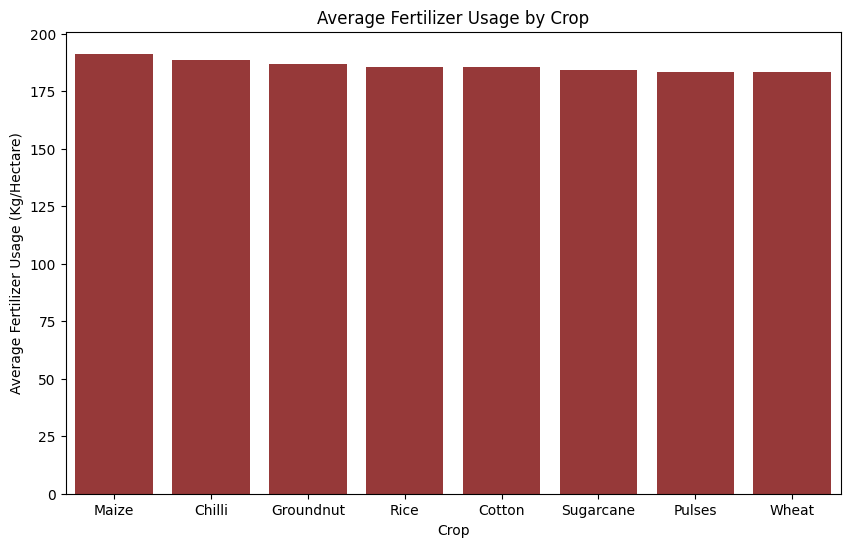

In [70]:
# Crop Variation

avg_fertilizer_usage_by_crop = (df.groupby('Crop')['Fertilizer_kg_ha'].mean().sort_values(ascending=False).reset_index())

display(avg_fertilizer_usage_by_crop)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_fertilizer_usage_by_crop, x='Crop', y='Fertilizer_kg_ha', color='brown', errorbar=None)

plt.xlabel('Crop')
plt.ylabel('Average Fertilizer Usage (Kg/Hectare)')
plt.title('Average Fertilizer Usage by Crop')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Fertilizer Usage by Crop' bar chart indicates that Maize has the highest average fertilizer usage, followed closely by Chilli and Groundnut. The usage across most other crops like Rice, Cotton, Sugarcane, Pulses, and Wheat is relatively similar and only slightly lower, suggesting that while there are minor variations, fertilizer application rates do not differ drastically among the crops in this dataset.</font>**

In [71]:
# Association with Yield

correlation_fertilizer_yield = yield_df['Fertilizer_kg_ha'].corr(yield_df['Yield_Tonnes_Ha'])

print(f'Correlation between Fertilizer Usage and Yield: {correlation_fertilizer_yield:.2f}')

Correlation between Fertilizer Usage and Yield: 0.00


**<font color='red'>Analytical Statement:<br>The Pearson Correlation coefficient between Fertilizer Usage and Yield is 0.00. This indicates an extremely weak, practically non-existent, linear relationship, suggesting that fertilizer usage, in this dataset, has no direct association with agricultural yield.</font>**

> ### **8.5 Pesticide Analysis: Seasonal Variation, Crop Variation and Association with Yield**
**TO FIND: How does pesticide usage vary across seasons and crops? Is it associated with yield?**

,Season,Pesticide_Litre_ha
0,Zaid,5.17
1,Kharif,5.08
2,Rabi,5.02


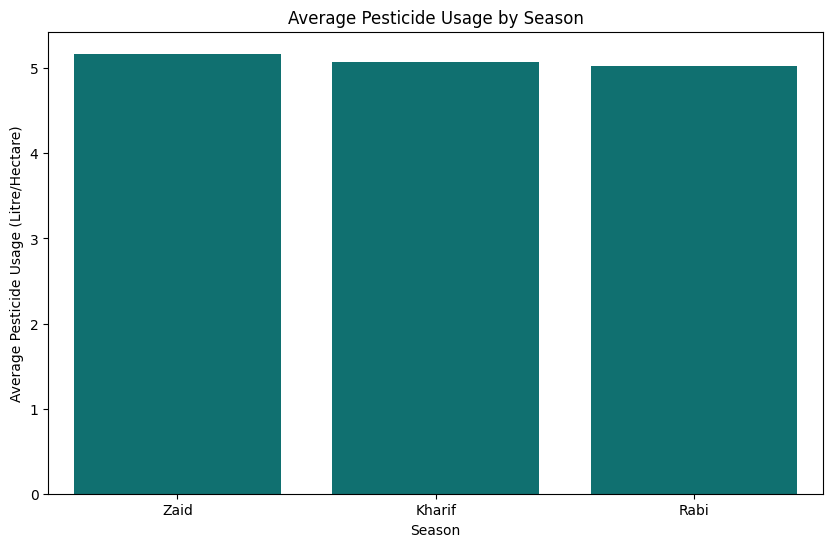

In [72]:
# Seasonal Variation

avg_pesticide_usage_by_season = (df.groupby('Season')['Pesticide_Litre_ha'].mean().sort_values(ascending=False).reset_index())

display(avg_pesticide_usage_by_season)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_pesticide_usage_by_season, x='Season', y='Pesticide_Litre_ha', color='teal', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Average Pesticide Usage (Litre/Hectare)')
plt.title('Average Pesticide Usage by Season')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Pesticide Usage by Season' bar chart indicates that Zaid has the highest average pesticide usage, followed closely by Kharif and Rabi. The differences across the three seasons are relatively small, suggesting that pesticide application rates remain fairly consistent across seasons in this dataset.</font>**

,Crop,Pesticide_Litre_ha
0,Groundnut,5.14
1,Chilli,5.13
2,Cotton,5.11
3,Maize,5.11
4,Rice,5.06
5,Sugarcane,5.04
6,Wheat,5.01
7,Pulses,4.99


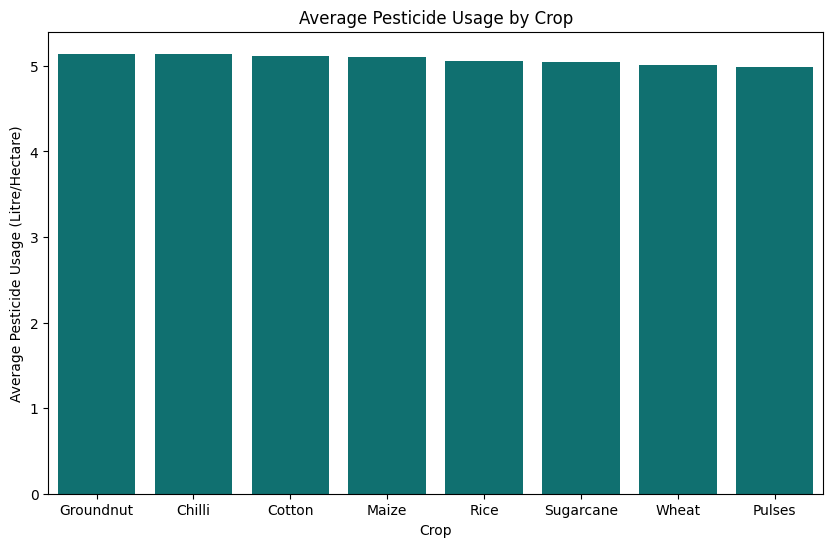

In [73]:
# Crop Variation

avg_pesticide_usage_by_crop = (df.groupby('Crop')['Pesticide_Litre_ha'].mean().sort_values(ascending=False).reset_index())

display(avg_pesticide_usage_by_crop)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_pesticide_usage_by_crop, x='Crop', y='Pesticide_Litre_ha', color='teal', errorbar=None)

plt.xlabel('Crop')
plt.ylabel('Average Pesticide Usage (Litre/Hectare)')
plt.title('Average Pesticide Usage by Crop')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Pesticide Usage by Crop' bar chart indicates that Groundnut has the highest average pesticide usage, followed closely by Chilli, Cotton, and Maize. Rice, Sugarcane, Wheat, and Pulses show slightly lower average usage, although the differences across crops are relatively small, suggesting that pesticide application rates are fairly consistent among the crops in this dataset.</font>**

In [74]:
# Association wit Yield

correlation_pesticide_yield = yield_df['Pesticide_Litre_ha'].corr(yield_df['Yield_Tonnes_Ha'])

print(f'Correlation between Pesticide Usage and Yield: {correlation_pesticide_yield:.2f}')

Correlation between Pesticide Usage and Yield: -0.01


**<font color='red'>Analytical Statement:<br>The correlation coefficient between Pesticide Usage and Yield is -0.01, indicating a negligible negative association. This suggests that pesticide usage has almost no linear relationship with agricultural yield in the given dataset.</font>**

> ### **8.6 Nutrient Analysis: Seasonal Variation, Crop Variation and Association with Yield**
**TO FIND: How does nutrient usage vary across seasons and crops? Is it associated with yield?**

,Season,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
0,Kharif,120.02,58.10,105.30
1,Rabi,120.40,57.31,103.93
2,Zaid,120.53,58.13,105.42


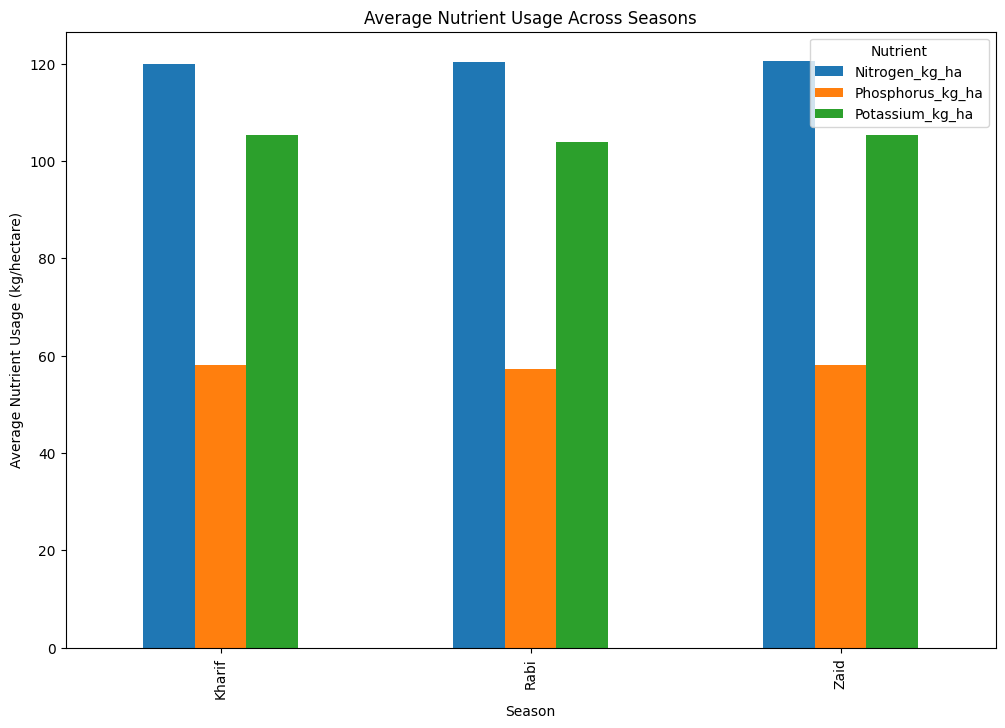

In [90]:
# Seasonal Variation

season_npk = (df.groupby('Season')[['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha']].mean().reset_index())

display(season_npk)

# Visualization:

season_npk.plot(x='Season',y=['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha'], kind='bar', figsize=(12, 8))

plt.title('Average Nutrient Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Nutrient Usage (kg/hectare)')
plt.legend(title='Nutrient')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average NPK Usage Across Seasons' bar chart shows that Nitrogen has the highest average usage across all three seasons, followed by Potassium and Phosphorus. NPK usage remains relatively consistent across Kharif, Rabi, and Zaid, with only minor seasonal variations in the average application of each nutrient.</font>**

,Crop,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
0,Chilli,120.01,58.64,106.41
1,Cotton,116.89,57.17,103.05
2,Groundnut,119.74,56.16,103.48
3,Maize,121.69,57.80,105.25
4,Pulses,120.44,57.90,105.34
5,Rice,119.92,57.79,104.73
6,Sugarcane,122.18,59.37,104.72
7,Wheat,121.52,57.93,105.10


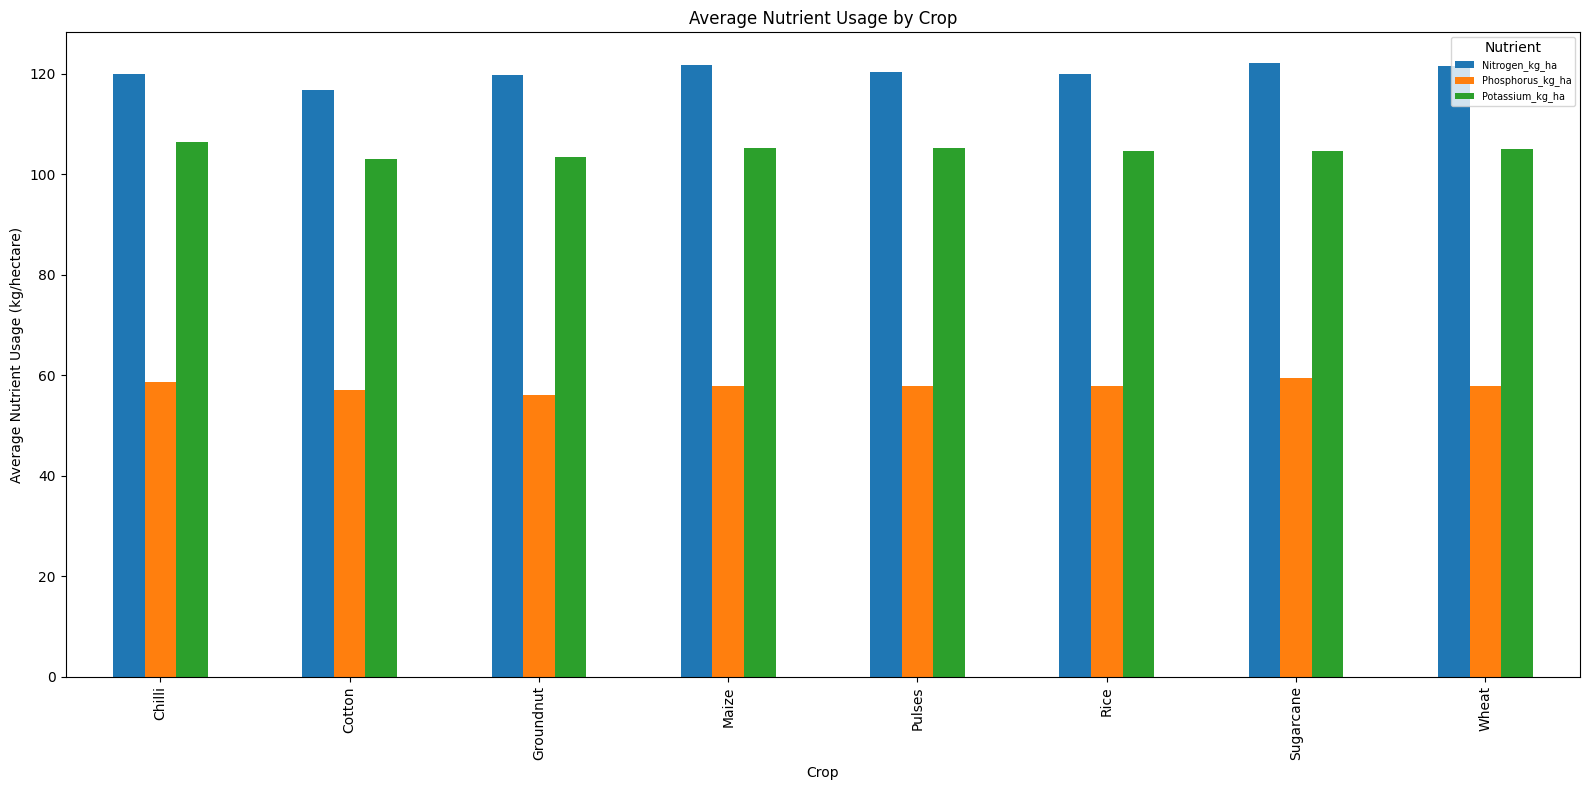

In [89]:
# Crop Variation

crop_npk = (df.groupby('Crop')[['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha']].mean().reset_index())

display(crop_npk)

crop_npk.plot(x='Crop', y=['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha'], kind='bar',figsize=(16, 8))

plt.title('Average Nutrient Usage by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Nutrient Usage (kg/hectare)')
plt.legend(title='Nutrient', fontsize='x-small')
plt.tight_layout()
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Nutrient Usage by Crop' bar chart shows that Nitrogen has the highest average application across all crops, followed by Potassium and Phosphorus. Maize has the highest average Nitrogen usage, while Sugarcane has the highest average Phosphorus usage. Overall, nutrient application levels are relatively consistent across crops, with only minor variations in NPK usage.</font>**

In [77]:
# Association with Yield

nutrient_correlations = {
    'Nitrogen': yield_df['Nitrogen_kg_ha'].corr(yield_df['Yield_Tonnes_Ha']),
    'Phosphorus': yield_df['Phosphorus_kg_ha'].corr(yield_df['Yield_Tonnes_Ha']),
    'Potassium': yield_df['Potassium_kg_ha'].corr(yield_df['Yield_Tonnes_Ha'])
}

for nutrient, correlation in nutrient_correlations.items():
    print(f'Correlation between {nutrient} and Yield: {correlation:.2f}')

Correlation between Nitrogen and Yield: 0.05
Correlation between Phosphorus and Yield: 0.05
Correlation between Potassium and Yield: 0.00


**<font color='red'>Analytical Statement:<br>The correlation analysis shows that Nitrogen and Phosphorus each have a correlation of 0.05 with Yield, while Potassium has a correlation of 0.00. These values indicate negligible positive associations, suggesting that individual NPK usage has very little linear relationship with agricultural yield in this dataset.</font>**

> ### **9. FINANCIAL PERFORMANCE ANALYSIS**<br>

Questions:<br>
1. Which season has the highest average profit per hectare?
2. Which season has the highest profit margin?
3. Which season has the highest ROI?
4. Which crops generate the highest profit per hectare?
5. Which crop has the highest profit margin?
6. Which crop has the highest ROI?
7. Is market price associated with profit?
8. Which states have the highest average profit per hectare?

> ### **9.1 Average Profit Per Hectare by Season**
**TO FIND: Which season has the highest average profit per hectare?**

,Season,Profit_per_Hectare
0,Kharif,"21,881.81"
1,Rabi,"10,361.68"
2,Zaid,"-2,636.52"


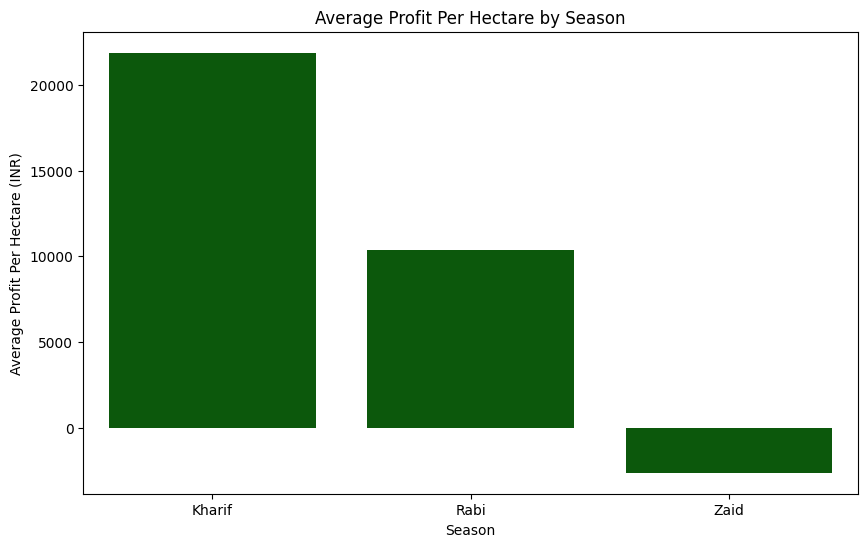

In [91]:
avg_profit_per_hectare_by_season = (df.groupby('Season')['Profit_per_Hectare'].mean().sort_values(ascending=False).reset_index())

display(avg_profit_per_hectare_by_season)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_profit_per_hectare_by_season, x='Season', y='Profit_per_Hectare', color='darkgreen', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Average Profit Per Hectare (INR)')
plt.title('Average Profit Per Hectare by Season')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Profit Per Hectare by Season' bar chart indicates that Kharif has the highest average profit per hectare, followed by Rabi. In contrast, Zaid shows a negative average profit per hectare, indicating an average loss during this season. This highlights substantial variation in financial performance across seasons.</font>**

> ### **9.2 Average Profit Margin by Season**
**TO FIND: Which season has the highest profit margin?**

,Season,Profit_Margin_pct
0,Kharif,-38.64
1,Rabi,-44.27
2,Zaid,-69.35


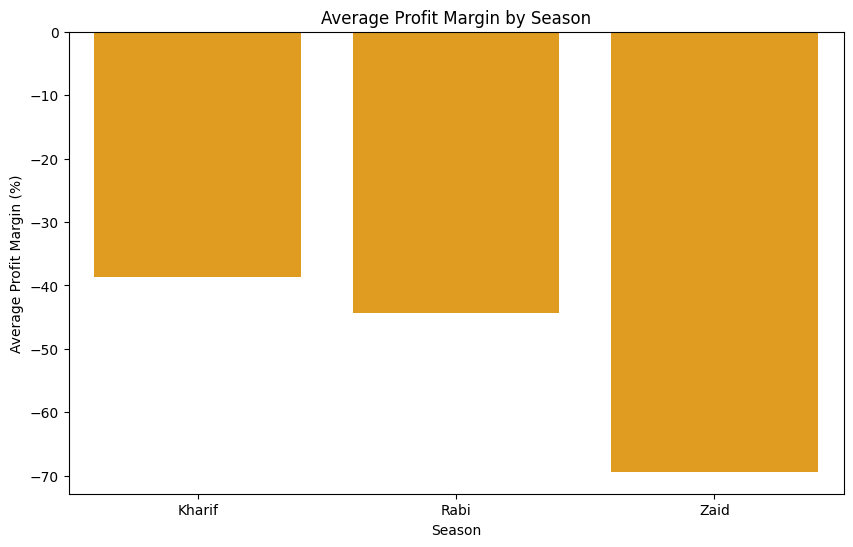

In [79]:
avg_profit_margin_by_season = (df.groupby('Season')['Profit_Margin_pct'].mean().sort_values(ascending=False).reset_index())

display(avg_profit_margin_by_season)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_profit_margin_by_season, x='Season', y='Profit_Margin_pct', color='orange', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Average Profit Margin (%)')
plt.title('Average Profit Margin by Season')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Profit Margin by Season' bar chart indicates that all three seasons have negative average profit margins. Kharif has the highest (least negative) profit margin, followed by Rabi, while Zaid has the lowest profit margin, indicating comparatively weaker financial performance.</font>**

> ### **9.3 Average ROI by Season**
**TO FIND: Which season has the highest ROI?**

,Season,ROI_pct
0,Kharif,35.45
1,Rabi,17.60
2,Zaid,-2.47


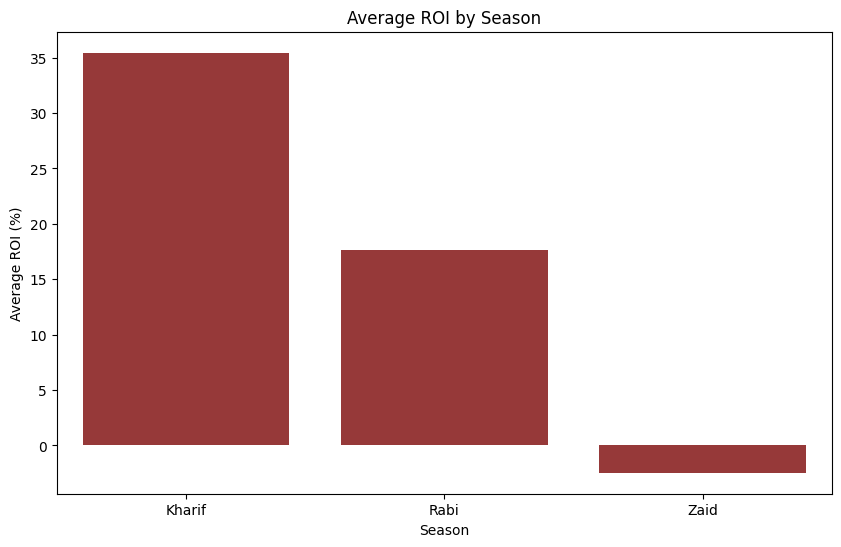

In [80]:
avg_roi_by_season = (df.groupby('Season')['ROI_pct'].mean().sort_values(ascending=False).reset_index())

display(avg_roi_by_season)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_roi_by_season, x='Season', y='ROI_pct', color='brown', errorbar=None)

plt.xlabel('Season')
plt.ylabel('Average ROI (%)')
plt.title('Average ROI by Season')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average ROI by Season' bar chart indicates that Kharif has the highest average ROI at approximately 35%, followed by Rabi at around 18%. Zaid has a negative average ROI of approximately -2%, indicating comparatively weaker investment returns during this season.</font>**

> ### **9.4 Average Profit Per Hectare by Crop**
**TO FIND: Which crops generate the highest profit per hectare?**

,Crop,Profit_per_Hectare
0,Sugarcane,"97,169.92"
1,Chilli,"92,123.09"
2,Cotton,"16,354.22"
3,Groundnut,"7,443.69"
4,Pulses,-693.36
5,Maize,"-10,203.08"
6,Rice,"-13,137.46"
7,Wheat,"-15,968.82"


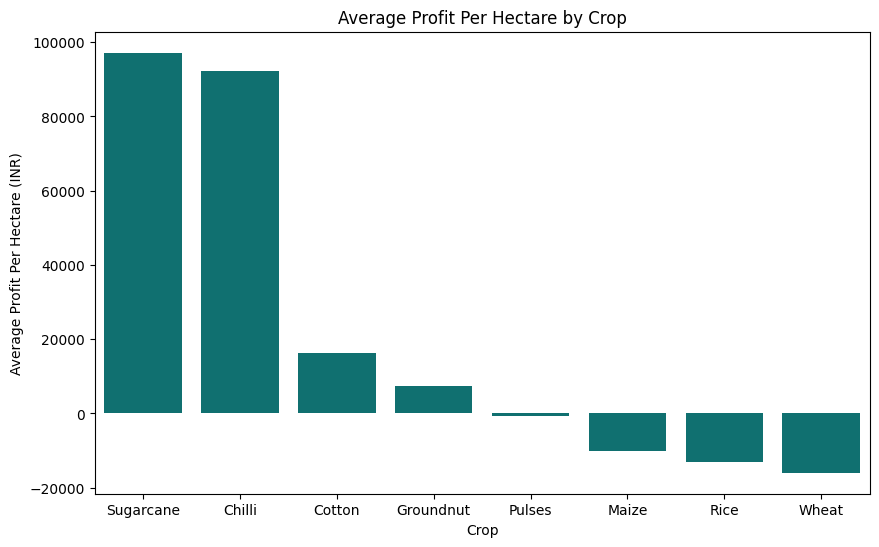

In [92]:
avg_profit_per_hectare_by_crop = (df.groupby('Crop')['Profit_per_Hectare'].mean().sort_values(ascending=False).reset_index())

display(avg_profit_per_hectare_by_crop)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_profit_per_hectare_by_crop, x='Crop', y='Profit_per_Hectare', color='teal', errorbar=None)

plt.xlabel('Crop')
plt.ylabel('Average Profit Per Hectare (INR)')
plt.title('Average Profit Per Hectare by Crop')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Profit Per Hectare by Crop' bar chart indicates that Sugarcane has the highest average profit per hectare, followed by Chilli. Cotton and Groundnut show positive but considerably lower average profits, while Pulses, Maize, Rice, and Wheat have negative average profits per hectare, indicating comparatively weaker financial performance for these crops.</font>**

> ### **9.5 Average Profit Margin by Crop**
**TO FIND: Which crop has the highest profit margin?**

,Crop,Profit_Margin_pct
0,Chilli,33.78
1,Sugarcane,27.35
2,Cotton,-8.23
3,Groundnut,-28.66
4,Pulses,-36.48
5,Maize,-81.54
6,Wheat,-91.70
7,Rice,-99.37


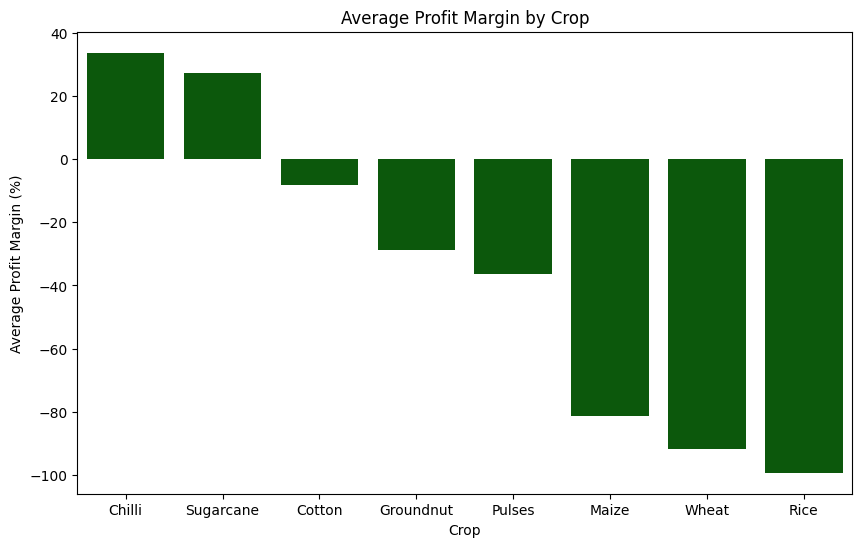

In [82]:
avg_profit_margin_by_crop = (df.groupby('Crop')['Profit_Margin_pct'].mean().sort_values(ascending=False).reset_index())

display(avg_profit_margin_by_crop)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_profit_margin_by_crop, x='Crop', y='Profit_Margin_pct', color='darkgreen', errorbar=None)

plt.xlabel('Crop')
plt.ylabel('Average Profit Margin (%)')
plt.title('Average Profit Margin by Crop')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Profit Margin by Crop' bar chart indicates that Chilli has the highest average profit margin, followed by Sugarcane. Cotton, Groundnut, Pulses, Maize, Wheat, and Rice have negative average profit margins, with Rice showing the lowest margin, indicating comparatively weaker financial performance.</font>**

> ### **9.6 Average ROI by Crop**
**TO FIND: Which crop has the highest ROI?**

,Crop,ROI_pct
0,Sugarcane,149.93
1,Chilli,143.04
2,Cotton,27.01
3,Groundnut,13.03
4,Pulses,0.86
5,Maize,-13.94
6,Rice,-17.83
7,Wheat,-22.99


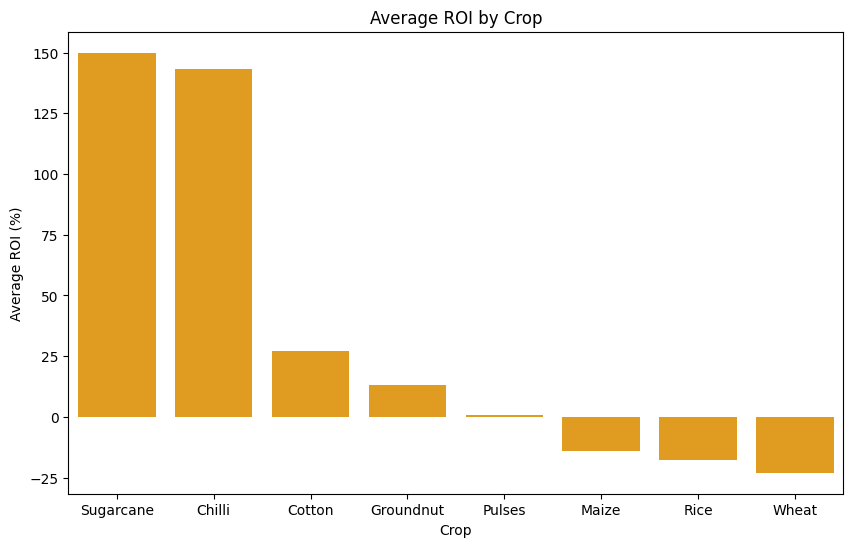

In [83]:
avg_roi_by_crop = (df.groupby('Crop')['ROI_pct'].mean().sort_values(ascending=False).reset_index())

display(avg_roi_by_crop)

# Visualization:

plt.figure(figsize=(10, 6))

sns.barplot(data=avg_roi_by_crop, x='Crop', y='ROI_pct', color='orange', errorbar=None)

plt.xlabel('Crop')
plt.ylabel('Average ROI (%)')
plt.title('Average ROI by Crop')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average ROI by Crop' bar chart indicates that Sugarcane has the highest average ROI at approximately 150%, followed by Chilli at around 143%. Cotton and Groundnut show positive but lower returns, while Pulses has a near-zero ROI. Maize, Rice, and Wheat have negative average ROI, with Wheat showing the lowest return, indicating comparatively weaker investment performance.</font>**

> ### **9.7 Market Price VS Profit**
**TO FIND: Is market price associated with profit?**

In [84]:
correlation_market_price_profit = df['Market_Price_INR_Tonne'].corr(df['Profit_INR'])

print(f'Correlation between Market Price and Profit: {correlation_market_price_profit:.2f}')

Correlation between Market Price and Profit: 0.23


**<font color='red'>Analytical Statement:<br>The correlation coefficient between Market Price and Profit is 0.23, indicating a weak positive association. This suggests that higher market prices tend to be associated with higher profit, but the relationship is relatively weak and other factors also contribute to variations in profit.</font>**



> ### **9.8 Average Profit Per Hectare by States**
**TO FIND: Which states have the highest average profit per hectare?**

,State,Profit_per_Hectare
0,Punjab,"15,776.79"
1,Telangana,"15,054.88"
2,Maharashtra,"14,899.93"
3,Karnataka,"14,843.76"
4,Gujarat,"12,992.59"
5,Tamil Nadu,"12,927.05"
6,Madhya Pradesh,"11,058.19"
7,Andhra Pradesh,"11,006.67"


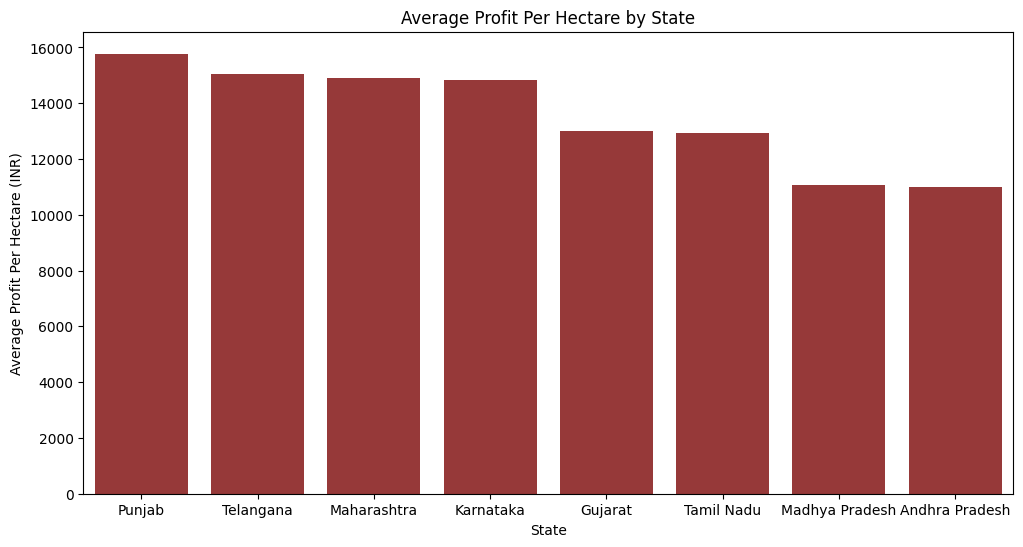

In [93]:
state_profitability = (df.groupby('State')['Profit_per_Hectare'].mean().sort_values(ascending=False).reset_index())

display(state_profitability)

# Visualization:

plt.figure(figsize=(12, 6))

sns.barplot(data=state_profitability, x='State', y='Profit_per_Hectare', color='brown', errorbar=None)

plt.xlabel('State')
plt.ylabel('Average Profit Per Hectare (INR)')
plt.title('Average Profit Per Hectare by State')
plt.show()

**<font color='red'>Analytical Statement:<br>The 'Average Profit Per Hectare by State' bar chart indicates that Punjab has the highest average profit per hectare, followed by Telangana, Maharashtra, and Karnataka. Gujarat and Tamil Nadu show moderate average profits, while Madhya Pradesh and Andhra Pradesh have the lowest, indicating some variation in financial performance across states.</font>**

> ### **10. OVERALL CORRELATION ANALYSIS**

Questions:
1. What are the strongest relationships among the original numerical variables in the agricultural dataset?
2. Which original numerical variables have the strongest association with agricultural yield?

> ### **10.1 Overall Strong Correlation Analysis**
**TO FIND: What are the strongest relationships among the original numerical variables in the agricultural dataset?**

In [86]:
# Original numerical columns only
numerical_columns = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

# Pearson correlation matrix
correlation_matrix = df[numerical_columns].corr(method='pearson')

# Upper triangle of the correlation matrix
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Convert correlations into a single table
correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    'Variable_1',
    'Variable_2',
    'Correlation'
]

# Calculate absolute correlation strength
correlation_pairs['Absolute_Correlation'] = (
    correlation_pairs['Correlation'].abs()
)

# Keep only strong correlations (|r| > 0.50)
strong_correlations = correlation_pairs[
    correlation_pairs['Absolute_Correlation'] >= 0.50
]

# Sort by absolute correlation strength
strong_correlations = strong_correlations.sort_values(
    'Absolute_Correlation',
    ascending=False
).reset_index(drop=True)

display(strong_correlations)

,Variable_1,Variable_2,Correlation,Absolute_Correlation
0,Farm_Area_Hectares,Total_Cost_INR,0.96,0.96
1,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,0.92,0.92
2,Revenue_INR,Profit_INR,0.89,0.89
3,Yield_Tonnes_Ha,Production_Tonnes,0.89,0.89
4,Production_Tonnes,Water_Efficiency_t_per_1000m3,0.81,0.81
5,Rainfall_mm,Disease_Pest_Risk_pct,0.62,0.62
6,Farm_Area_Hectares,Water_Used_m3,0.58,0.58
7,Total_Cost_INR,Water_Used_m3,0.58,0.58
8,Production_Tonnes,Revenue_INR,0.56,0.56
9,Production_Tonnes,Profit_INR,0.55,0.55


**<font color='red'>Analytical Statement:<br>The strong correlation analysis shows that Farm Area and Total Cost have the strongest positive association (0.96), followed by Yield and Water Efficiency (0.92). Revenue is strongly associated with Profit (0.89), while Yield also shows strong associations with Production (0.89) and Water Efficiency (0.92). Environmental variables such as Rainfall and Humidity show moderate positive associations with Disease/Pest Risk (0.62 and 0.55 respectively). Overall, the strongest relationships are observed among farm size, production, water efficiency, and financial variables.</font>**

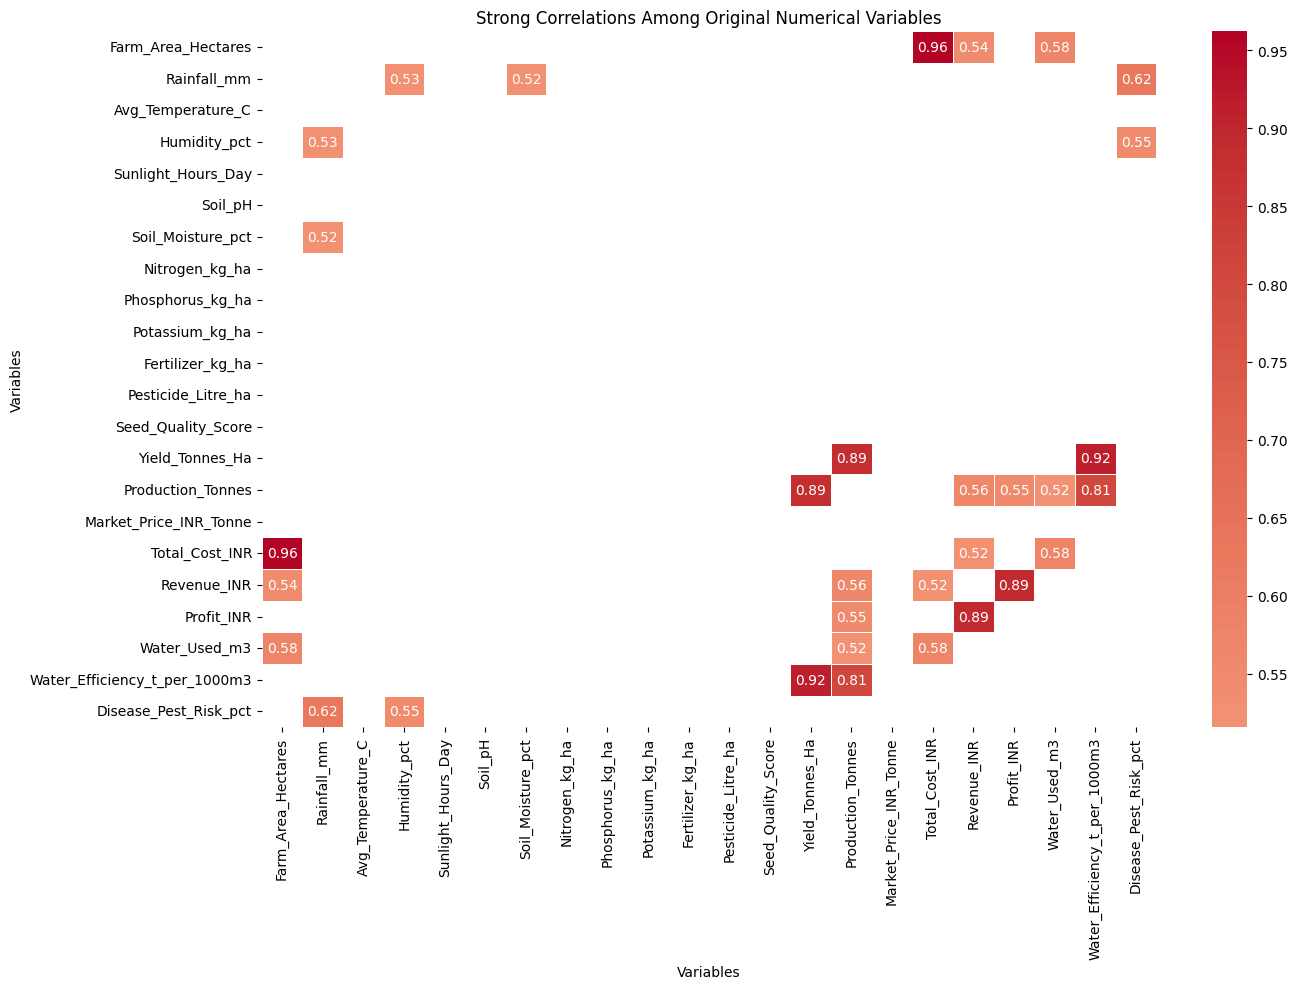

In [87]:
# Strong correlation matrix
strong_correlation_matrix = correlation_matrix.where(correlation_matrix.abs() >= 0.50)

mask = np.eye(len(correlation_matrix), dtype=bool)

# Visualization:
plt.figure(figsize=(14, 10))

sns.heatmap(
    strong_correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    mask=mask
)

plt.title('Strong Correlations Among Original Numerical Variables')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

**<font color='red'>Analytical Statement:<br>The heatmap visually confirms the strong positive relationships identified in the correlation analysis, with the strongest associations observed between Farm Area–Total Cost (0.96), Yield–Water Efficiency (0.92), Revenue–Profit (0.89), and Yield–Production (0.89).</font>**

>### **10.2 Yield Correlation Analysis**
**TO FIND: Which original numerical variables have the strongest association with agricultural yield?**

In [88]:
# Original numerical columns only
numerical_columns = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

# Calculate Pearson correlation using original columns only
correlation_matrix = df[numerical_columns].corr(method='pearson')

# Get correlations with Yield only
yield_correlations = (
    correlation_matrix['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(ascending=False)
    .reset_index()
)

yield_correlations.columns = [
    'Variable',
    'Correlation_with_Yield'
]

# Calculate absolute correlation
yield_correlations['Absolute_Correlation'] = (
    yield_correlations['Correlation_with_Yield'].abs()
)

# Keep only strong relationships (|r| > 0.50)
strong_yield_correlations = yield_correlations[
    yield_correlations['Absolute_Correlation'] > 0.50
]

# Sort by absolute correlation strength
strong_yield_correlations = strong_yield_correlations.sort_values(
    'Absolute_Correlation',
    ascending=False
)

strong_yield_correlations = strong_yield_correlations[
    ['Variable', 'Correlation_with_Yield']
]

display(strong_yield_correlations)

,Variable,Correlation_with_Yield
0,Water_Efficiency_t_per_1000m3,0.92
1,Production_Tonnes,0.89


**<font color='red'>Analytical Statement:<br>The data shows strong positive correlations with Yield, with Water Efficiency having the strongest relationship (0.92), followed by Production (0.89). This indicates that higher yield is closely associated with improved water efficiency and greater production.</font>**

> # <center><font color='blue'>**Overall Conclusion and Key Findings**</font><center>

### **Overall Conclusion:**

The Seasonal Agricultural Performance & Productivity Analysis reveals
significant differences in agricultural productivity, profitability, water efficiency, and risk across seasons, crops, and farming practices. Kharif emerges as the strongest overall season, delivering the highest average yield, total production, profit, ROI, and water efficiency, although it also faces the highest disease and pest risk. Sugarcane is the best-performing crop overall, consistently achieving the highest yield, production, profit, and ROI across seasons. The analysis also highlights water efficiency as the factor most strongly associated with yield, while most environmental variables and farming inputs show negligible direct linear relationships with yield. Overall, the findings demonstrate that crop selection, seasonal conditions, water management, and production efficiency play important roles in agricultural and financial performance.
<br>
<br>

---
<br>

### **Key Findings:**
1. Kharif was the best-performing season overall, with the highest average yield, total production, profitability, ROI, and water efficiency.
2. Zaid showed the weakest financial performance, with negative average profit, profit per hectare, profit margin, and ROI.
3. Sugarcane was the top-performing crop, consistently recording the highest yield and profit across Kharif, Rabi, and Zaid seasons.
4. Chilli also demonstrated strong profitability, particularly in terms of profit margin, while crops such as Maize, Rice, and Wheat showed weaker or negative financial performance.
5. Water efficiency had the strongest positive relationship with yield (0.92), followed by production (0.89), highlighting the importance of efficient water utilization.
6. Drip irrigation achieved the highest average yield, while Rainfed agriculture showed the highest water efficiency.
7. Environmental factors such as rainfall, temperature, soil moisture, humidity, and disease/pest risk showed negligible direct correlations with yield in this dataset.
8. Fertilizer, pesticide, seed quality, and individual NPK nutrient usage also showed little to no direct linear relationship with yield.
9. Farm Area and Total Cost had the strongest overall correlation (0.96), while Revenue and Profit were strongly associated (0.89).
10. Punjab recorded the highest average profit per hectare, followed by Telangana, Maharashtra, and Karnataka.
<br>

---
<br>


Overall, the analysis suggests that improving water efficiency, selecting high-performing crops such as Sugarcane, adopting effective irrigation practices, and considering seasonal profitability can support better agricultural productivity and financial outcomes.